In [1]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
import statsmodels.api as sm
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from joblib import Parallel, delayed
import io, base64
from scipy.stats import kruskal
from IPython.display import HTML, display
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.decomposition import IncrementalPCA 
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install imblearn
from sklearn.ensemble import GradientBoostingClassifier
!pip install xgboost
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
from statsmodels.stats.multitest import multipletests
from scipy.stats import t as tdist
from sklearn.svm import SVR
import shap
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, make_scorer
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import f_regression
from scipy.stats import f
from statsmodels.stats.multitest import multipletests
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from joblib import Parallel, delayed
from scipy.stats import t
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Loading

In [2]:
# Read the genetic data
genetic_data = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\GeneMarkers-95 varieties 1.csv")

genetic_data.head()

,taglo_id,ATLANTIC_124776,ESCORT_159228,ARGOS_120931,ALTURAS_329540,ELMUNDO_835520,NADINE_241950,VIOLETQUEEN_3345402,DEODARA_513721,MEMPHIS_2279529,...,DIAMANT_153502,INNOVATOR_234757,TRIPLE7_3347283,SPUNTA_283648,ANTI_118190,CARRERA_142554,FORTUS_3279866,SMART_1883446,SALINERO_253609,FABULA_171173
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,13,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,17,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
aroma_df= pd.read_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_df.csv')

aroma_df.head()

,Variety,"1-Heptanol (Floral, herbal)","1-Nonanol (Floral, waxy)","1-Octen-3-ol (Mushroom, earthy)","2,3-Butanedione (Butter, creamy, sweet)","2,4-Heptadienal (Fatty, green, oily)","2-Nonanone (Fatty, waxy)",2-Phenylethanol (No description),"3-Octanone (Mushroom, earthy)","Acetic acid (Vinegar, sour)",...,"Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Hexanol (Green, herbal, fatty)","Methanethiol (Sulfurous, cabbage)","Methional (Cooked potato, sulfurous)","Methyl butanoate (Fruity, apple, sweet)","Nonanal (Waxy, citrus, rose)","Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)","Phenylacetic acid (Honey, floral)"
0,ADORA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,1.000677e+06,1.117859e+06,0.0,0.0,0.000000e+00,1.794650e+07,2.410517e+06,0.000000e+00,406037.209782
1,AGRIA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,1.208483e+07,1.109952e+06,1.108374e+06,0.000000
2,ALOUETTE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,9.488242e+05,0.0,0.0,0.000000e+00,1.214480e+07,1.074904e+06,0.000000e+00,0.000000
3,ALTHEA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,2.108002e+06,2.754292e+06,0.0,0.0,1.908349e+07,3.830736e+07,0.000000e+00,3.065847e+06,0.000000
4,ALTURAS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.528957e+06,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,2.163269e+07,1.467772e+06,0.000000e+00,0.000000


In [4]:
sensory_pcs = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\save_results\sensory_pca_projection_knn_clean.csv")

# Data preparation

In [7]:
import pandas as pd
import numpy as np
import re

# -----------------------------
# Helper functions
# -----------------------------
def to_numeric(df):
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def norm_key(s):
    s = (str(s).upper().replace(".", "").replace(" ", ""))
    s = re.sub(r'\bR\b', '', s)
    s = re.sub(r'RUSSET', '', s)
    return s.split("_")[0]

# -----------------------------
# Genetic data
# -----------------------------
mrk_col = "TAGLO_ID" if "TAGLO_ID" in genetic_data.columns else genetic_data.columns[0]

G = (
    genetic_data.dropna(subset=[mrk_col])
    .drop_duplicates(subset=[mrk_col])
    .set_index(mrk_col)
)

G = to_numeric(G)
gd = G.T
gd.index.name = "Variety_raw"
gd.index = gd.index.map(norm_key)

# Collapse duplicates if multiple rows per variety
gd = gd.groupby(gd.index, observed=True).mean()
gd.columns = ["GEN__" + str(c) for c in gd.columns]
print("Genetic table after reshape:", gd.shape)

# -----------------------------
# Aroma data
# -----------------------------
af = aroma_df.copy()
assert "Variety" in af.columns, "aroma_df must have a 'Variety' column"
af["__key__"] = af["Variety"].map(norm_key)
af = af.set_index("__key__")

aroma_cols = [c for c in af.columns if c not in ["Variety", "index"]]
A = to_numeric(af[aroma_cols]).dropna(axis=1, how="all")
A = A.loc[:, A.std(ddof=0).fillna(0) > 0]  # drop constant cols
print(f"# aroma candidates (usable): {A.shape[1]}")
print("Sample aroma cols:", list(A.columns[:8]))

# -----------------------------
# Select top 10 aroma compounds by variance
# -----------------------------
compound_var = A.var(axis=0).sort_values(ascending=False)
top_by_variance = compound_var.head(10).index.tolist()
print("Top 10 most variable aroma compounds:", top_by_variance)

A_top = A[top_by_variance]

# -----------------------------
# Sensory PCs
# -----------------------------
assert "Variety" in sensory_pcs.columns, "sensory_pcs must have a 'Variety' column"
sensory_pcs["__key__"] = sensory_pcs["Variety"].map(norm_key)
sensory_pcs = sensory_pcs.set_index("__key__")

S = to_numeric(sensory_pcs.drop(columns=["Variety", "is_panel"], errors="ignore"))
print(f"# sensory PCs: {S.shape[1]}")
print("Sample sensory cols:", list(S.columns[:8]))

# -----------------------------
# Merge datasets
# -----------------------------
gk = gd.copy()
gk.index.name = "Variety"

# Genetics + all aroma
merged_snp_aroma = gk.join(A, how="inner")
print("Merged (SNPs + all aroma):", merged_snp_aroma.shape)

# Genetics + top aroma
merged_snp_aroma_top = gk.join(A_top, how="inner")
print("Merged (SNPs + top aroma):", merged_snp_aroma_top.shape)

# Genetics + sensory PCs
merged_snp_sensory = gk.join(S, how="inner")
print("Merged (SNPs + sensory PCs):", merged_snp_sensory.shape)

# Genetics + top aroma + sensory PCs
merged_all_top = gk.join(pd.concat([A_top, S], axis=1), how="inner")
print("Merged (SNPs + top aroma + sensory PCs):", merged_all_top.shape)


Genetic table after reshape: (94, 262434)
# aroma candidates (usable): 27
Sample aroma cols: ['1-Heptanol (Floral, herbal)', '1-Nonanol (Floral, waxy)', '1-Octen-3-ol (Mushroom, earthy)', '2,3-Butanedione (Butter, creamy, sweet)', '2,4-Heptadienal (Fatty, green, oily)', '2-Nonanone (Fatty, waxy)', '2-Phenylethanol (No description)', '3-Octanone (Mushroom, earthy)']
Top 10 most variable aroma compounds: ['Nonanal (Waxy, citrus, rose)', 'Methyl butanoate (Fruity, apple, sweet)', 'Hexanal (Green, grassy)', 'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)', 'Decanal (Citrus, floral)', 'Benzaldehyde (Almond, cherry, fruity)', '1-Octen-3-ol (Mushroom, earthy)', 'Pentanal (Green, fatty, pungent)', 'Hexanol (Green, herbal, fatty)', 'Hexanoic acid (Fatty, cheesy, sweaty)']
# sensory PCs: 3
Sample sensory cols: ['PC1', 'PC2', 'PC3']
Merged (SNPs + all aroma): (94, 262461)
Merged (SNPs + top aroma): (94, 262444)
Merged (SNPs + sensory PCs): (93, 262437)
Merged (SNPs + top aroma + sensory 

# Exploratory analysis:

# 1.HCA (Ward, Euclidean) on SNP-linked aroma profiles (EDA)

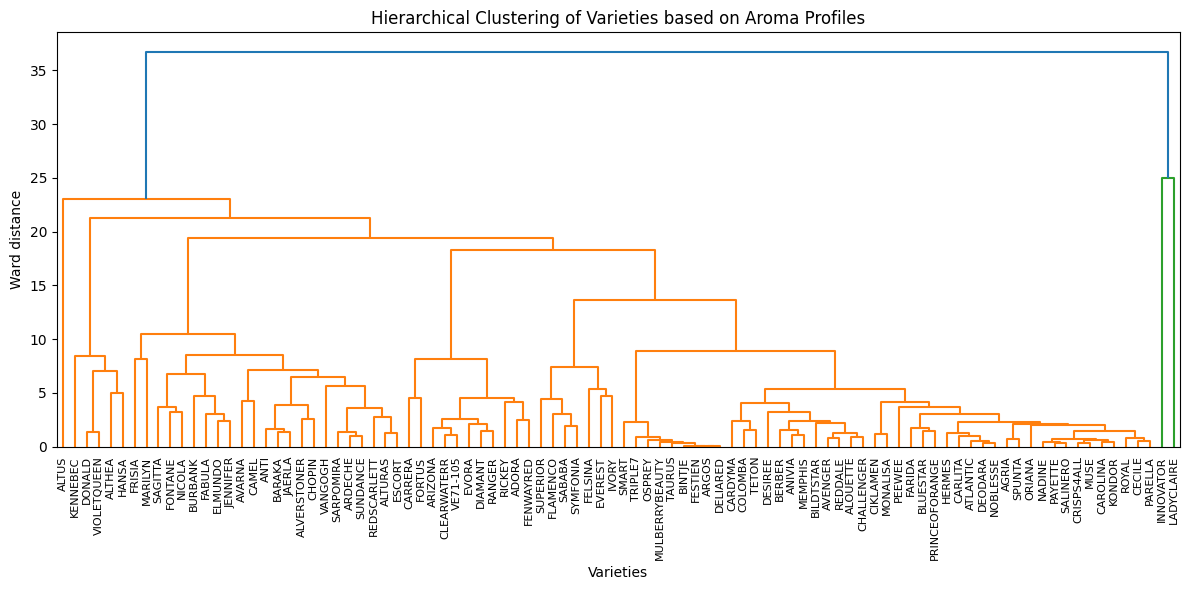

In [8]:

X = merged_snp_aroma[aroma_cols].copy().fillna(0.0)

# scale columns so compounds contribute equally
Xz = pd.DataFrame(
    StandardScaler().fit_transform(X.values),
    index=X.index,
    columns=aroma_cols
)

# hierarchical clustering
Z = linkage(Xz.values, method="ward", metric="euclidean")

# plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=X.index.tolist(), leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering of Varieties based on Aroma Profiles")
plt.xlabel("Varieties")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()


Most varieties clustered into two major groups with several smaller subgroups, while a few varieties ( Innovator, Lady Claire) appeared as outliers

# Select K-best for clustering using silhouette score

In [9]:
# Evaluate k
k_range = range(2, 11)
sil, ch, db = [], [], []
D = pdist(Xz, metric="euclidean")

for k in k_range:
    labs = fcluster(Z, k, criterion="maxclust")
    sil.append(silhouette_score(Xz, labs))
    ch.append(calinski_harabasz_score(Xz, labs))
    db.append(davies_bouldin_score(Xz, labs))

# Choose best k by max silhouette
best_k = k_range[int(np.argmax(sil))]
print("k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin")
for k, si, c, d in zip(k_range, sil, ch, db):
    print(f"{k:2d} |   {si:8.3f}   |     {c:10.1f}     |     {d:6.3f}")
print(f"\nSelected k = {best_k} (by silhouette)")

# Final labels
clusters = fcluster(Z, best_k, criterion="maxclust")

# Store separately (instead of adding to merged_snp_aroma)
aroma_clusters = pd.Series(clusters, index=merged_snp_aroma.index, name="AromaCluster")

print("\nCluster sizes:\n", aroma_clusters.value_counts().sort_index())
# Remove old cluster columns from merged_snp_aroma
merged_snp_aroma = merged_snp_aroma.drop(
    columns=[c for c in merged_snp_aroma.columns if c.startswith("AromaCluster_")],
    errors="ignore"
)


k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin
 2 |      0.756   |           33.2     |      0.863
 3 |      0.718   |           28.9     |      0.171
 4 |      0.690   |           29.2     |      0.180
 5 |      0.455   |           31.1     |      0.501
 6 |      0.275   |           33.7     |      0.822
 7 |      0.321   |           37.9     |      0.811
 8 |      0.331   |           38.9     |      0.864
 9 |      0.335   |           38.0     |      0.877
10 |      0.244   |           36.7     |      0.864

Selected k = 2 (by silhouette)

Cluster sizes:
 AromaCluster
1    92
2     2
Name: count, dtype: int64


Beacuse of outliers it shows two cluster, probably it is more than two . a more meaningful clustering if we do clustering as multiple subgroups instead of just detecting outliers.

# 2.HCA on merged_snp_sensory 

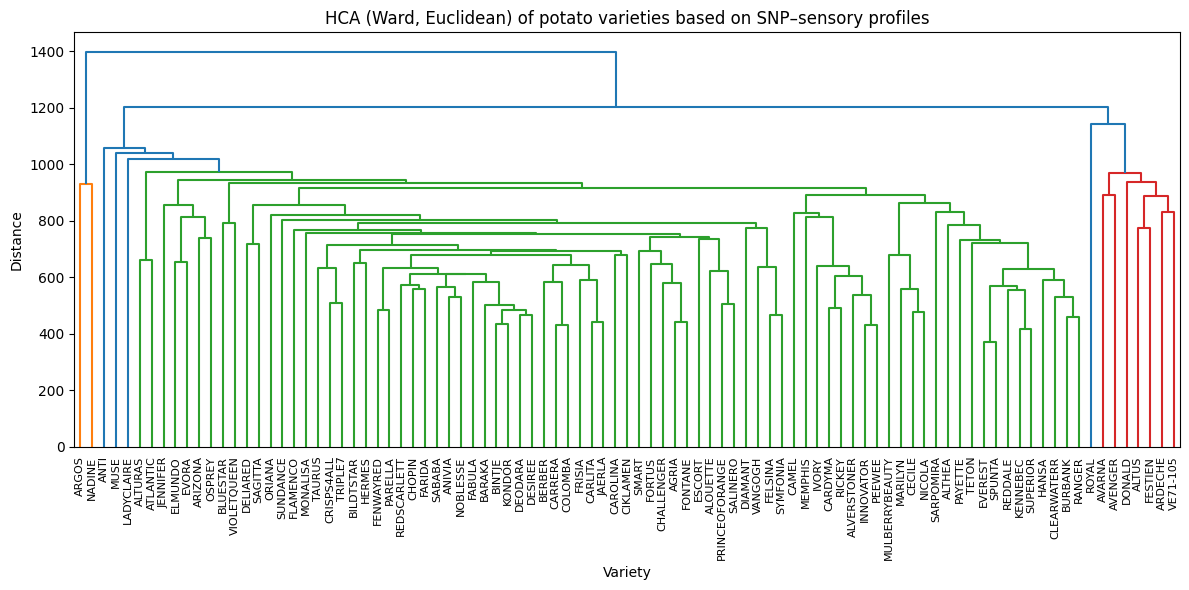

In [10]:

# Drop non-numeric and missing columns
X = merged_snp_sensory.select_dtypes(include=[np.number]).dropna(axis=1, how="any")

# Drop rows with NaN after selection
X = X.dropna(axis=0, how="any")

# Standardize
Xz = (X - X.mean()) / X.std(ddof=0)

# Replace any inf/-inf created during scaling with NaN, then drop
Xz = Xz.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how="any")

# Compute distance + linkage
D = pdist(Xz, metric="euclidean")
Z = linkage(D, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=Xz.index, leaf_rotation=90, leaf_font_size=8, color_threshold=0.7*max(Z[:,2]))
plt.title("HCA (Ward, Euclidean) of potato varieties based on SNP–sensory profiles")
plt.xlabel("Variety")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


Hierarchical clustering of the SNP–sensory dataset grouped the potato varieties into several distinct clusters. Two larger clusters were observed alongside smaller subgroups, with a few varieties separating as clear outliers(Nadin, Argos). This indicates that genetic variation partly explains sensory differences, and some varieties have unique sensory-linked SNP profiles.

In [11]:
# Evaluate k
k_range = range(2, 11)
sil, ch, db = [], [], []
D = pdist(Xz, metric="euclidean")

for k in k_range:
    labs = fcluster(Z, k, criterion="maxclust")
    sil.append(silhouette_score(Xz, labs))
    ch.append(calinski_harabasz_score(Xz, labs))
    db.append(davies_bouldin_score(Xz, labs))

# Choose best k by max silhouette
best_k = k_range[int(np.argmax(sil))]
print("k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin")
for k, si, c, d in zip(k_range, sil, ch, db):
    print(f"{k:2d} |   {si:8.3f}   |     {c:10.1f}     |     {d:6.3f}")
print(f"\nSelected k = {best_k} (by silhouette)")

# Final labels
clusters = fcluster(Z, best_k, criterion="maxclust")

# Store separately (instead of adding to merged_snp_aroma)
aroma_clusters = pd.Series(clusters, index=merged_snp_sensory.index, name="AromaCluster")

print("\nCluster sizes:\n", aroma_clusters.value_counts().sort_index())
# Remove old cluster columns from merged_snp_aroma
merged_snp_sensory = merged_snp_sensory.drop(
    columns=[c for c in merged_snp_sensory.columns if c.startswith("AromaCluster_")],
    errors="ignore"
)



k  |  Silhouette  |  Calinski-Harabasz  |  Davies-Bouldin
 2 |      0.278   |            3.8     |      1.351
 3 |      0.165   |            3.4     |      2.760
 4 |      0.152   |            3.2     |      2.114
 5 |      0.153   |            3.0     |      1.829
 6 |      0.154   |            2.9     |      1.640
 7 |      0.155   |            2.8     |      1.507
 8 |      0.101   |            2.7     |      1.517
 9 |      0.102   |            2.7     |      1.427
10 |      0.087   |            2.6     |      1.609

Selected k = 2 (by silhouette)

Cluster sizes:
 AromaCluster
1     2
2    91
Name: count, dtype: int64


the clusters are imbalance it probably beacuse of outiers so we will check the outliers.
During clustering, a few varieties appeared as outliers in both SNP–aroma and SNP–sensory datasets. Because these outliers strongly affected model performance, they should be excluded from training to improve prediction accuracy. They are reported separately as varieties with distinct profiles.

# Feature engineering

SNPs: cleaned, normalized variety names, and reduced dimensionality with PCA.

Aroma: kept relevant compounds, removed constants, log-transformed, standardized, and extracted PCs.

Sensory: imported panel PCA scores, normalized names, kept numeric PCs.


#  Feature selection and preprocessing

# 1. PCA on snps

PCA was applied separately to SNPs. For SNPs, dimensionality reduction was needed due to the very high number of markers.

# 2. MAF filter 

Total SNPs before filtering: 262434
SNPs kept after MAF > 0.05: 58978
Original dataset: (94, 262461)
After MAF filter: (94, 59005)


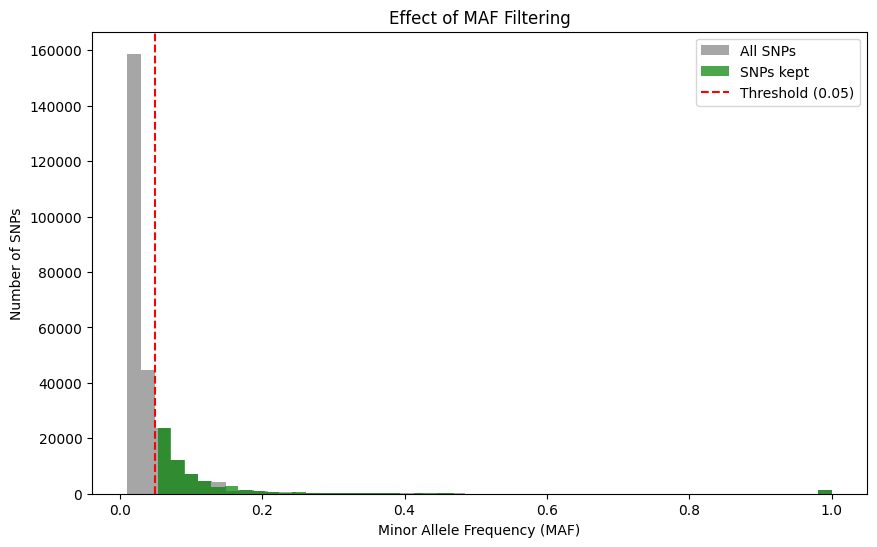

In [12]:
# Identify SNP columns
snp_cols = [c for c in merged_snp_aroma.columns if c.startswith("GEN__")]
print(f"Total SNPs before filtering: {len(snp_cols)}")

# Compute MAF
maf = merged_snp_aroma[snp_cols].apply(
    lambda x: x.value_counts(normalize=True).min(), axis=0
)
# Apply filter (keep SNPs with MAF > 0.05)
snp_keep = maf[maf > 0.05].index.tolist()
print(f"SNPs kept after MAF > 0.05: {len(snp_keep)}")

# Filter dataset
merged_maf = merged_snp_aroma[snp_keep + [c for c in merged_snp_aroma.columns if not c.startswith("GEN__")]]


print("Original dataset:", merged_snp_aroma.shape)
print("After MAF filter:", merged_maf.shape)

# Plot MAF distribution
plt.figure(figsize=(10,6))
plt.hist(maf.values, bins=50, alpha=0.7, color="gray", label="All SNPs")
plt.hist(maf[snp_keep].values, bins=50, alpha=0.7, color="green", label="SNPs kept")
plt.axvline(0.05, color="red", linestyle="--", label="Threshold (0.05)")
plt.xlabel("Minor Allele Frequency (MAF)")
plt.ylabel("Number of SNPs")
plt.title("Effect of MAF Filtering")
plt.legend()
plt.show()

Most SNPs cluster around very low MAF values.After filtering,we still retain a large number of informative SNPs (green bars).The red dashed line (threshold = 0.05) seems reasonable.

# 3. GWAS- LD_pruning

In [11]:

#  Define helper functions

def run_gwas(df, trait, snp_cols):
    """
    Run GWAS for a single trait.
    Returns a DataFrame with SNP, p_value, and p_fdr.
    """
    y = df[trait].astype(float).values
    n = len(y)
    gwas_results = []

    for snp in snp_cols:
        x = df[snp].fillna(df[snp].mode().iloc[0]).astype(float).values
        if x.std() == 0:
            continue
        x = (x - x.mean()) / (x.std() + 1e-6)

        r = np.corrcoef(x, y)[0, 1]
        if np.isnan(r):
            continue
        r = np.clip(r, -0.999999, 0.999999)

        F_val = (r**2) / ((1 - r**2) / (n - 2))
        p_val = f.sf(F_val, 1, n - 2)
        gwas_results.append((snp, p_val))

    gwas_df = pd.DataFrame(gwas_results, columns=["SNP", "p_value"])
    gwas_df["p_fdr"] = multipletests(gwas_df["p_value"], method="fdr_bh")[1]
    return gwas_df


def ld_prune(X_df, threshold=0.9, max_snps=2000):
    """
    Perform LD pruning on SNP matrix.
    Removes SNPs that are highly correlated (|r| > threshold).
    """
    X_df = X_df.loc[:, X_df.std() > 0]
    if X_df.shape[1] > max_snps:
        X_df = X_df.iloc[:, :max_snps]
    if X_df.shape[1] <= 1:
        return X_df

    corr = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return X_df.drop(columns=to_drop)



#  Prepare traits
# SNP columns (already defined earlier as snp_cols)
trait_cols = [
    c for c in merged_snp_aroma.columns
    if c not in snp_cols and np.issubdtype(merged_snp_aroma[c].dtype, np.number)
]

# Keep only traits with variance > 0
aroma_nonconst = merged_snp_aroma[trait_cols].loc[:, merged_snp_aroma[trait_cols].std() > 0]


#  Run GWAS per trait
all_gwas = []  # collect per-trait GWAS results

for trait in aroma_nonconst.columns:
    print(f"\n[trait] {trait}")
    gwas_df = run_gwas(merged_snp_aroma, trait, snp_cols)

    if gwas_df.empty:
        print("  No valid SNPs. Skipping.")
        continue

    top_snps = gwas_df.sort_values("p_fdr").head(500)["SNP"].tolist()
    if len(top_snps) == 0:
        print("  No significant SNPs. Skipping.")
        continue

    # SNP matrix
    X = merged_snp_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning. Skipping.")
        continue

    #  add trait column before saving
    gwas_df["Trait"] = trait
    all_gwas.append(gwas_df)

    # (optional: continue with modeling, e.g., Kernel Ridge)



#  Save all GWAS results
all_gwas_df = pd.concat(all_gwas, ignore_index=True)
all_gwas_df.to_csv("gwas_aroma_all_traits.csv", index=False)

print("\n All GWAS results saved to gwas_aroma_all_traits.csv")



[trait] 1-Nonanol (Floral, waxy)

[trait] 1-Octen-3-ol (Mushroom, earthy)

[trait] 2,3-Butanedione (Butter, creamy, sweet)

[trait] Acetic acid (Vinegar, sour)

[trait] Benzaldehyde (Almond, cherry, fruity)

[trait] Butanal, 3-methyl- (Fruity, malty, chocolate)

[trait] Butanoic acid (Sweaty, cheesy)

[trait] Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)

[trait] Decanal (Citrus, floral)

[trait] Dimethyl trisulfide (Garlic, onion, sulfurous)

[trait] Furfural (Sweet, almond, caramel)

[trait] Heptanal (Green, fatty, citrus-like)

[trait] Hexanal (Green, grassy)

[trait] Hexanoic acid (Fatty, cheesy, sweaty)

[trait] Methional (Cooked potato, sulfurous)

[trait] Nonanal (Waxy, citrus, rose)

[trait] Octanal (Citrus, fruity)

[trait] Pentanal (Green, fatty, pungent)

 All GWAS results saved to gwas_aroma_all_traits.csv


# Gwas per trait- sensory prediction

In [ ]:
merged_snp_sensory

# Define helper functions
def run_gwas(df, trait, snp_cols):
    """
    Run GWAS for a single trait.
    Returns a DataFrame with SNP, p_value, and p_fdr.
    """
    y = df[trait].astype(float).values
    n = len(y)
    gwas_results = []

    for snp in snp_cols:
        x = df[snp].fillna(df[snp].mode().iloc[0]).astype(float).values
        if x.std() == 0:
            continue
        x = (x - x.mean()) / (x.std() + 1e-6)

        r = np.corrcoef(x, y)[0, 1]
        if np.isnan(r):
            continue
        r = np.clip(r, -0.999999, 0.999999)

        F_val = (r**2) / ((1 - r**2) / (n - 2))
        p_val = f.sf(F_val, 1, n - 2)
        gwas_results.append((snp, p_val))

    gwas_df = pd.DataFrame(gwas_results, columns=["SNP", "p_value"])
    gwas_df["p_fdr"] = multipletests(gwas_df["p_value"], method="fdr_bh")[1]
    return gwas_df


def ld_prune(X_df, threshold=0.9, max_snps=2000):
    """
    Perform LD pruning on SNP matrix.
    Removes SNPs that are highly correlated (|r| > threshold).
    """
    X_df = X_df.loc[:, X_df.std() > 0]
    if X_df.shape[1] > max_snps:
        X_df = X_df.iloc[:, :max_snps]
    if X_df.shape[1] <= 1:
        return X_df

    corr = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return X_df.drop(columns=to_drop)


# =====================================================
# 2. Prepare traits for sensory PCs
# =====================================================
pcs = ["PC1", "PC2", "PC3"]
all_gwas_sensory = []

for trait in pcs:
    print(f"\n[trait] {trait}")
    gwas_df = run_gwas(merged_snp_sensory, trait, snp_cols)

    if gwas_df.empty:
        print("  No valid SNPs. Skipping.")
        continue

    top_snps = gwas_df.sort_values("p_fdr").head(500)["SNP"].tolist()
    if len(top_snps) == 0:
        print("  No significant SNPs. Skipping.")
        continue

    # SNP matrix
    X = merged_snp_sensory[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning. Skipping.")
        continue

    # add trait column before saving
    gwas_df["Trait"] = trait
    all_gwas_sensory.append(gwas_df)


# =====================================================
# 3. Save all GWAS results
# =====================================================
all_gwas_df_sensory = pd.concat(all_gwas_sensory, ignore_index=True)
all_gwas_df_sensory.to_csv("gwas_sensory_PCs.csv", index=False)

print("\n All GWAS results for PC1–PC3 saved to gwas_sensory_PCs.csv")



[trait] PC1


# 4. Multi-trait / multivariate association

In [13]:


TOP_N = 10  # take ten important markers
# SNP & Aroma columns
snp_cols = [c for c in merged_snp_aroma.columns if c.startswith("GEN__")]

aroma_cols = [
    c for c in merged_snp_aroma.columns
    if not c.startswith("GEN__")
]

print("Number of SNPs:", len(snp_cols))
print("Number of Aroma traits:", len(aroma_cols))
print("Example Aroma traits:", aroma_cols[:10])


# Build Y (aroma traits only)
Y = merged_snp_aroma[aroma_cols].astype(float).fillna(0).values
n, p = Y.shape  # n = samples, p = traits

# Standardize Y
Y = (Y - Y.mean(axis=0)) / (Y.std(axis=0, ddof=0) + 1e-6)


# MAF filter
maf = merged_snp_aroma[snp_cols].apply(
    lambda x: x.value_counts(normalize=True).min(), axis=0
)
snp_keep = maf[maf > 0.05].index.tolist()
print(f"[filter] Kept {len(snp_keep)} SNPs (from {len(snp_cols)}) after MAF > 0.05")


# Multi-trait association (like MANOVA)
results = []
for snp in snp_keep[:2000]:  # limit for speed (adjust/remove in full run)
    x = merged_snp_aroma[snp].fillna(
        merged_snp_aroma[snp].mode().iloc[0]
    ).astype(float).values
    x = (x - x.mean()) / (x.std() + 1e-6)

    # Correlation with all traits
    r_vec = np.dot(x, Y) / (n - 1)  # correlation for each trait
    ssq = np.sum(r_vec**2)          # sum of squared correlations

    # Approximate F-test (like Pillai’s trace)
    F_val = (ssq / p) / ((1 - ssq) / (n - p - 1))
    p_val = f.sf(F_val, p, n - p - 1)

    results.append((snp, F_val, p_val))


# Results DataFrame
multi_df = pd.DataFrame(results, columns=["SNP", "F_value", "p_value"])

# FDR correction
multi_df["p_fdr"] = multipletests(multi_df["p_value"], method="fdr_bh")[1]


# Top SNPs for aroma traits
top_hit_multi_aroma = multi_df.sort_values("p_fdr").head(TOP_N)
print(f"\nTop {TOP_N} SNPs (Aroma traits):")
print(top_hit_multi_aroma)


multi_df.to_csv("aromasnp_muti_gwas.csv", index=False)
top_hit_multi_aroma.to_csv("top_hit_multi_aroma.csv", index=False)

print("\n Results saved to:")
print(" - aromasnp_muti_gwas.csv (all SNPs)")
print(f" - top_hit_multi_aroma.csv (Top {TOP_N} SNPs)")


Number of SNPs: 262434
Number of Aroma traits: 18
Example Aroma traits: ['1-Nonanol (Floral, waxy)', '1-Octen-3-ol (Mushroom, earthy)', '2,3-Butanedione (Butter, creamy, sweet)', 'Acetic acid (Vinegar, sour)', 'Benzaldehyde (Almond, cherry, fruity)', 'Butanal, 3-methyl- (Fruity, malty, chocolate)', 'Butanoic acid (Sweaty, cheesy)', 'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)', 'Decanal (Citrus, floral)', 'Dimethyl trisulfide (Garlic, onion, sulfurous)']
[filter] Kept 58978 SNPs (from 262434) after MAF > 0.05

Top 10 SNPs (Aroma traits):
             SNP    F_value       p_value         p_fdr
483    GEN__7103  17.265919  9.400722e-20  1.880144e-16
553    GEN__8109   9.060113  1.955281e-12  4.888203e-10
539    GEN__7956   9.060113  1.955281e-12  4.888203e-10
547    GEN__8030   9.060113  1.955281e-12  4.888203e-10
522    GEN__7840   9.060113  1.955281e-12  4.888203e-10
1327  GEN__18377   9.060113  1.955281e-12  4.888203e-10
568    GEN__8253   9.060113  1.955281e-12  4.888203e

Unlike single-trait GWAS (where no strong signals were detected for compounds like Hexanal), the multivariate association test identified SNPs significantly linked to variation across multiple aroma traits. This suggests that some markers may influence groups of correlated volatiles rather than individual compounds in isolation.

In [14]:

df_sensory = merged_snp_sensory.copy()

# SNPs
snp_cols = [c for c in df_sensory.columns if c.startswith("GEN__")]

# Sensory PCs 
sensory_cols = [c for c in df_sensory.columns if c.startswith("PC")]
Y = df_sensory[sensory_cols].astype(float).fillna(0).values
n, p = Y.shape  # n = samples, p = traits

# Standardize Y
Y = (Y - Y.mean(axis=0)) / (Y.std(axis=0, ddof=0) + 1e-6)

# MAF filter
maf = df_sensory[snp_cols].apply(lambda x: x.value_counts(normalize=True).min(), axis=0)
snp_keep = maf[maf > 0.05].index.tolist()
print(f"[filter] Kept {len(snp_keep)} SNPs (from {len(snp_cols)}) after MAF > 0.05")

#  Multi-trait association (similar to MANOVA) 
results = []
for snp in snp_keep[:2000]:  # limit for speed (remove limit for full run)
    x = df_sensory[snp].fillna(df_sensory[snp].mode().iloc[0]).astype(float).values
    x = (x - x.mean()) / (x.std() + 1e-6)

    # Correlation with all PCs
    r_vec = np.dot(x, Y) / (n - 1)
    ssq = np.sum(r_vec**2)

    # Approximate F-test
    F_val = (ssq / p) / ((1 - ssq) / (n - p - 1))
    p_val = f.sf(F_val, p, n - p - 1)

    results.append((snp, F_val, p_val))

# Collect results
multi_df_sensory = pd.DataFrame(results, columns=["SNP", "F_value", "p_value"])

# FDR correction
multi_df_sensory["p_fdr"] = multipletests(multi_df_sensory["p_value"], method="fdr_bh")[1]

# Top SNPs
top_hits_sensory = multi_df_sensory.sort_values("p_fdr").head(10)
print(top_hits_sensory)


[filter] Kept 58588 SNPs (from 262434) after MAF > 0.05
             SNP    F_value       p_value     p_fdr
1910  GEN__22968  13.293374  3.022891e-07  0.000605
1336  GEN__18557   9.836576  1.142671e-05  0.005713
574    GEN__8423   9.836576  1.142671e-05  0.005713
573    GEN__8413   9.836576  1.142671e-05  0.005713
1934  GEN__23084   7.553143  1.472738e-04  0.046408
1927  GEN__23036   7.553143  1.472738e-04  0.046408
1905  GEN__22929   7.467904  1.624276e-04  0.046408
1899  GEN__22889   6.124533  7.786687e-04  0.071094
1243  GEN__17190   5.602216  1.449323e-03  0.071094
576    GEN__8595   5.602216  1.449323e-03  0.071094


In [15]:
# for Aroma take top 100 SNPs based on FDR
top_snps_aroma = multi_df.sort_values("p_fdr").head(100)["SNP"].tolist()
print(f"[aroma] Selected {len(top_snps_aroma)} top SNPs for per-trait GWAS")

# for Sensory: take top 100 SNPs based on FDR
top_snps_sensory = multi_df_sensory.sort_values("p_fdr").head(100)["SNP"].tolist()
print(f"[sensory] Selected {len(top_snps_sensory)} top SNPs for per-trait GWAS")

[aroma] Selected 100 top SNPs for per-trait GWAS
[sensory] Selected 100 top SNPs for per-trait GWAS


In [16]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.dummy import DummyRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# -------------------------
# Evaluation function
# -------------------------
def evaluate_model_cv(name, model, X, Y, cv):
    fold_scores = []
    for train_idx, test_idx in cv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test)

        fold_r2 = r2_score(Y_test, Y_pred, multioutput="uniform_average")
        fold_scores.append(fold_r2)
    return {"Model": name, "R2_mean": np.mean(fold_scores), "R2_all": fold_scores}

# -------------------------
# Cross-validation setup
# -------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

# 1) Dummy baseline
dummy = DummyRegressor(strategy="mean")
results.append(evaluate_model_cv("DummyMean", dummy, X_pca, Y, cv))

# 2) PLS Regression (test with 2–5 latent components)
for n_comp in [2, 3, 5]:
    pls = PLSRegression(n_components=n_comp)
    results.append(evaluate_model_cv(f"PLSR_{n_comp}comp", pls, X_pca, Y, cv))

# 3) Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=500, 
    max_depth=None, 
    random_state=42,
    n_jobs=-1
)
results.append(evaluate_model_cv("RandomForest", rf, X_pca, Y, cv))

# Collect results
results_df = pd.DataFrame(results)
print("\n=== Model Comparison (PCA SNPs → Aroma traits) ===")
print(results_df)


NameError: name 'X_pca' is not defined

# 5. Variance thresholding

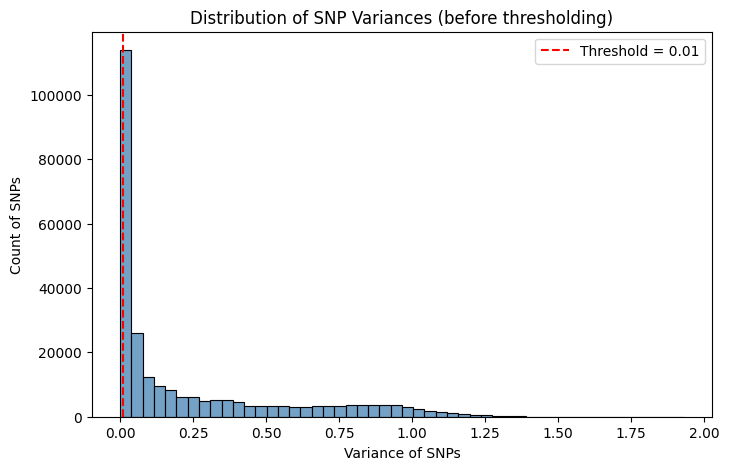

Original SNPs: 262434
Remaining SNPs after threshold: 261110


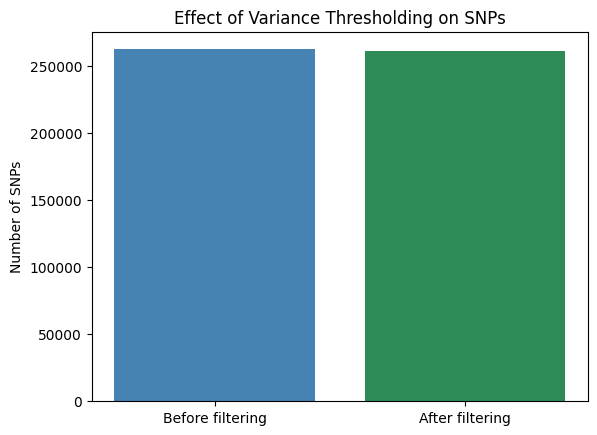

In [ ]:

# SNP-only dataset
X = merged_snp_aroma[[c for c in merged_snp_aroma.columns if c.startswith("GEN__")]].astype(float)

# Calculate variances
variances = X.var(axis=0)

# Plot distribution of SNP variances
plt.figure(figsize=(8,5))
sns.histplot(variances, bins=50, kde=False, color="steelblue")
plt.axvline(0.01, color="red", linestyle="--", label="Threshold = 0.01")
plt.xlabel("Variance of SNPs")
plt.ylabel("Count of SNPs")
plt.title("Distribution of SNP Variances (before thresholding)")
plt.legend()
plt.show()

# Apply variance threshold
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)

print(f"Original SNPs: {X.shape[1]}")
print(f"Remaining SNPs after threshold: {X_selected.shape[1]}")
# Count before/after
before = X.shape[1]
after = X_selected.shape[1]

plt.bar(["Before filtering", "After filtering"], [before, after], color=["steelblue", "seagreen"])
plt.ylabel("Number of SNPs")
plt.title("Effect of Variance Thresholding on SNPs")
plt.show()


# Model prediction

# Gwas per trait + Linear Models + with outlier

In [ ]:

from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)


#  Evaluation helper
def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


# Load GWAS results
gwas_all = pd.read_csv("gwas_aroma_all_traits.csv")

results_lin = []
results_ridge = []

# loop over traits
for trait in gwas_all["Trait"].unique():
    print(f"\n[Modeling - Linear vs Ridge] Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs for modeling.")
        continue

    # SNP matrix
    X = merged_snp_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # standardize + get target
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = merged_snp_aroma[trait].astype(float).values


    # LinearRegression
    lin_model = LinearRegression()
    lin_model.fit(X_scaled, y)
    y_pred_lin = lin_model.predict(X_scaled)

    lin_metrics = evaluate_regression(y, y_pred_lin)
    lin_cv_r2 = np.mean(cross_val_score(lin_model, X_scaled, y, cv=cv, scoring="r2"))

    results_lin.append({
        "Trait": trait,
        "n_SNPs": X_pruned.shape[1],
        "CV_Best_R2": lin_cv_r2,
        **lin_metrics
    })


    # Ridge Regression
    ridge_model = Ridge(alpha=1.0)
    ridge_model.fit(X_scaled, y)
    y_pred_ridge = ridge_model.predict(X_scaled)

    ridge_metrics = evaluate_regression(y, y_pred_ridge)
    ridge_cv_r2 = np.mean(cross_val_score(ridge_model, X_scaled, y, cv=cv, scoring="r2"))

    results_ridge.append({
        "Trait": trait,
        "n_SNPs": X_pruned.shape[1],
        "CV_Best_R2": ridge_cv_r2,
        **ridge_metrics
    })



# Save results separately
results_df_lin = pd.DataFrame(results_lin)
results_df_ridge = pd.DataFrame(results_ridge)

results_df_lin.to_csv("linear_regression_metrics_all_traits.csv", index=False)
results_df_ridge.to_csv("ridge_regression_metrics_all_traits.csv", index=False)

print("\n LinearRegression results saved to linear_regression_metrics_all_traits.csv")
display(results_df_lin.sort_values("CV_Best_R2", ascending=False).head(10))

print("\n Ridge results saved to ridge_regression_metrics_all_traits.csv")
display(results_df_ridge.sort_values("CV_Best_R2", ascending=False).head(10))



[Modeling - Linear vs Ridge] Trait: 1-Nonanol (Floral, waxy)


NameError: name 'ld_prune' is not defined

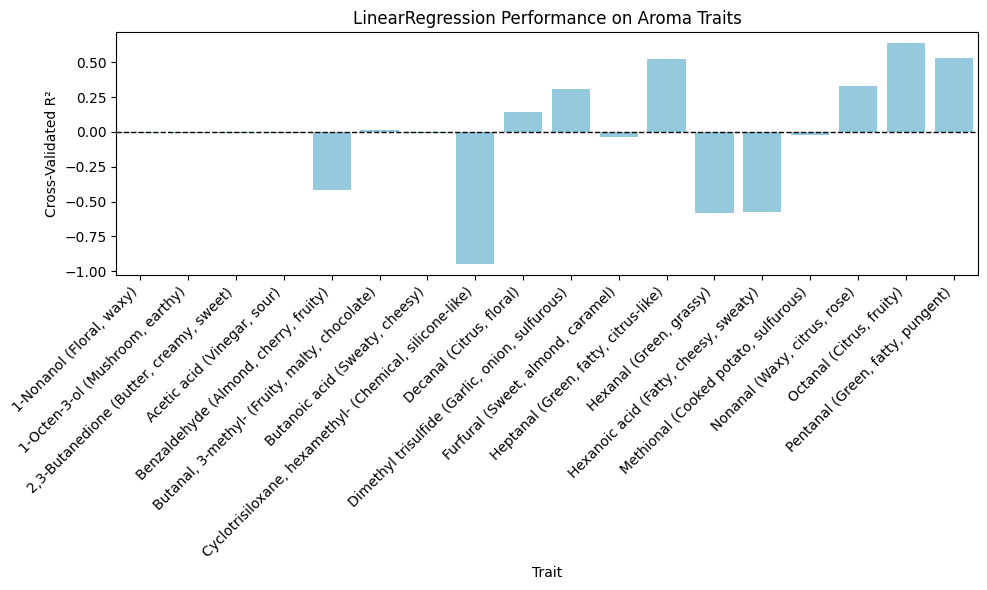

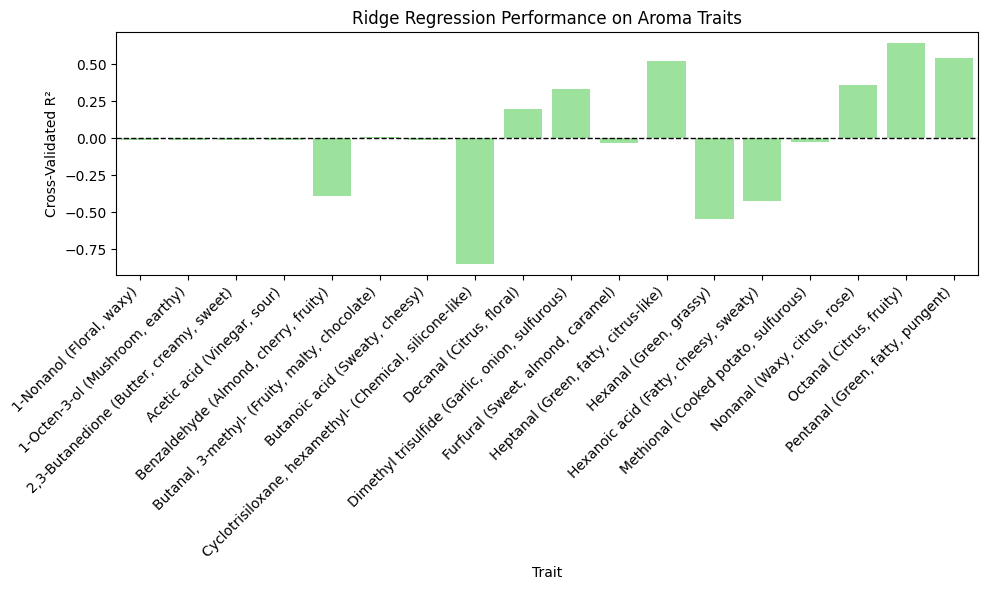

In [ ]:

# Barplot for LinearRegression
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df_lin,
    x="Trait",
    y="CV_Best_R2",
    color="skyblue"
)
plt.xticks(rotation=45, ha="right")
plt.title("LinearRegression Performance on Aroma Traits")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


# Barplot for Ridge
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df_ridge,
    x="Trait",
    y="CV_Best_R2",
    color="lightgreen"
)
plt.xticks(rotation=45, ha="right")
plt.title("Ridge Regression Performance on Aroma Traits")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()



[Modeling - Linear vs Ridge] Trait: 1-Nonanol (Floral, waxy)

[Modeling - Linear vs Ridge] Trait: 1-Octen-3-ol (Mushroom, earthy)

[Modeling - Linear vs Ridge] Trait: 2,3-Butanedione (Butter, creamy, sweet)

[Modeling - Linear vs Ridge] Trait: Acetic acid (Vinegar, sour)

[Modeling - Linear vs Ridge] Trait: Benzaldehyde (Almond, cherry, fruity)

[Modeling - Linear vs Ridge] Trait: Butanal, 3-methyl- (Fruity, malty, chocolate)

[Modeling - Linear vs Ridge] Trait: Butanoic acid (Sweaty, cheesy)

[Modeling - Linear vs Ridge] Trait: Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)

[Modeling - Linear vs Ridge] Trait: Decanal (Citrus, floral)

[Modeling - Linear vs Ridge] Trait: Dimethyl trisulfide (Garlic, onion, sulfurous)

[Modeling - Linear vs Ridge] Trait: Furfural (Sweet, almond, caramel)

[Modeling - Linear vs Ridge] Trait: Heptanal (Green, fatty, citrus-like)

[Modeling - Linear vs Ridge] Trait: Hexanal (Green, grassy)

[Modeling - Linear vs Ridge] Trait: Hexanoic acid (Fatt

,Trait,n_SNPs,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
1,"1-Octen-3-ol (Mushroom, earthy)",90,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00
2,"2,3-Butanedione (Butter, creamy, sweet)",90,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00
11,"Heptanal (Green, fatty, citrus-like)",306,0.509674,1.000000,1.916052e-18,1.384215e-09,1.061195e-09
16,"Octanal (Citrus, fruity)",234,0.465476,1.000000,9.944640e-18,3.153512e-09,2.513570e-09
9,"Dimethyl trisulfide (Garlic, onion, sulfurous)",220,0.445791,1.000000,1.071961e-18,1.035356e-09,7.723468e-10
17,"Pentanal (Green, fatty, pungent)",174,0.350546,1.000000,8.170972e-18,2.858491e-09,1.825718e-09
8,"Decanal (Citrus, floral)",25,0.217511,0.746266,2.011621e+12,1.418316e+06,1.085429e+06
15,"Nonanal (Waxy, citrus, rose)",152,0.105381,1.000000,3.039644e-16,1.743457e-08,1.355049e-08
5,"Butanal, 3-methyl- (Fruity, malty, chocolate)",2,0.070865,0.259084,2.624808e+12,1.620126e+06,1.255903e+06
0,"1-Nonanol (Floral, waxy)",51,-0.011111,1.000000,1.552754e-21,3.940500e-11,1.749555e-11



 Ridge results saved to ridge_regression_metrics_all_traits_no_outliers.csv


,Trait,n_SNPs,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
1,"1-Octen-3-ol (Mushroom, earthy)",90,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00
2,"2,3-Butanedione (Butter, creamy, sweet)",90,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00
11,"Heptanal (Green, fatty, citrus-like)",306,0.511992,0.999976,3.502299e+06,1.871443e+03,1.344180e+03
16,"Octanal (Citrus, fruity)",234,0.477107,0.999837,8.152734e+07,9.029249e+03,7.338911e+03
9,"Dimethyl trisulfide (Garlic, onion, sulfurous)",220,0.459588,0.999736,1.418835e+08,1.191148e+04,8.793621e+03
17,"Pentanal (Green, fatty, pungent)",174,0.362235,0.999619,4.220368e+08,2.054353e+04,1.523604e+04
8,"Decanal (Citrus, floral)",25,0.265101,0.744748,2.023650e+12,1.422550e+06,1.107548e+06
15,"Nonanal (Waxy, citrus, rose)",152,0.166091,0.998577,8.643017e+10,2.939901e+05,2.274284e+05
5,"Butanal, 3-methyl- (Fruity, malty, chocolate)",2,0.066345,0.259074,2.624843e+12,1.620137e+06,1.256784e+06
0,"1-Nonanol (Floral, waxy)",51,-0.011111,0.999697,4.244075e+04,2.060115e+02,1.838776e+02


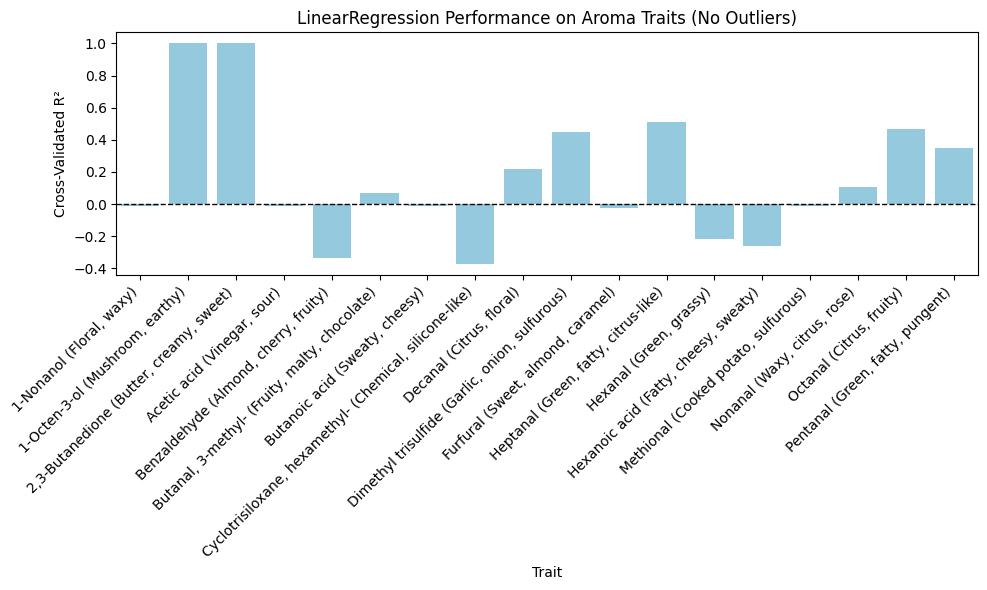

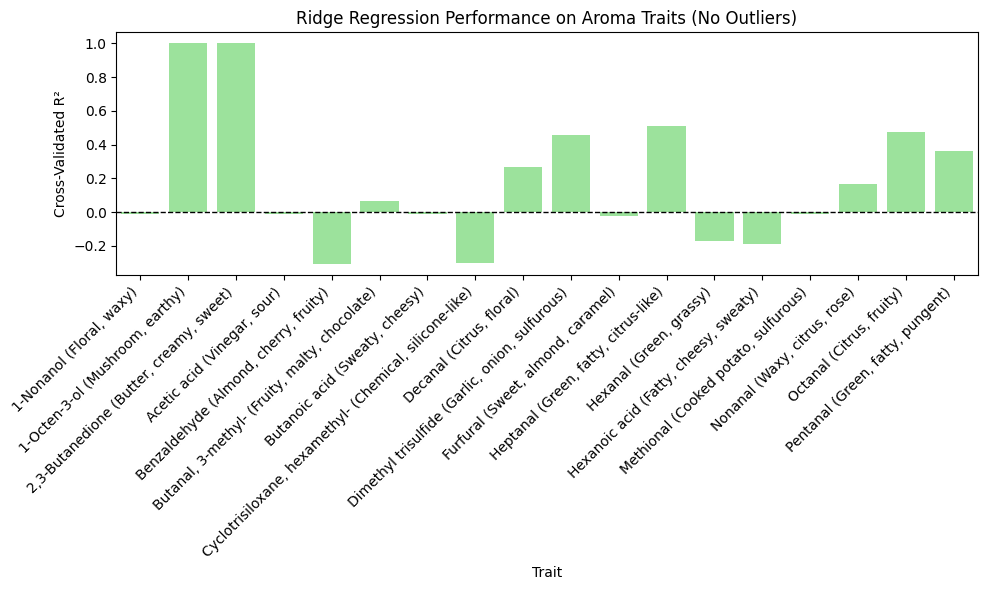

In [ ]:
# GWAS per trait + Linear Models (without outliers)
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error
)


#  Config
cv = KFold(n_splits=5, shuffle=True, random_state=42)


#  Evaluation helper
def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


# Load GWAS results + remove outliers

file_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\gwas_aroma_all_traits.csv"

gwas_all= pd.read_csv(file_path)

# Drop outliers
outliers = ["INNOVATOR", "LADY CLAIRE"]
df_aroma = merged_snp_aroma.drop(index=[o for o in outliers if o in merged_snp_aroma.index])

results_lin = []
results_ridge = []

# loop over traits
for trait in gwas_all["Trait"].unique():
    print(f"\n[Modeling - Linear vs Ridge] Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs for modeling.")
        continue

    # SNP matrix (without outliers)
    X = df_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # standardize + get target (without outliers)
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = df_aroma[trait].astype(float).values


    # LinearRegression
    lin_model = LinearRegression()
    lin_model.fit(X_scaled, y)
    y_pred_lin = lin_model.predict(X_scaled)

    lin_metrics = evaluate_regression(y, y_pred_lin)
    lin_cv_r2 = np.mean(cross_val_score(lin_model, X_scaled, y, cv=cv, scoring="r2"))

    results_lin.append({
        "Trait": trait,
        "n_SNPs": X_pruned.shape[1],
        "CV_Best_R2": lin_cv_r2,
        **lin_metrics
    })

  
    # Ridge Regression
    ridge_model = Ridge(alpha=1.0)
    ridge_model.fit(X_scaled, y)
    y_pred_ridge = ridge_model.predict(X_scaled)

    ridge_metrics = evaluate_regression(y, y_pred_ridge)
    ridge_cv_r2 = np.mean(cross_val_score(ridge_model, X_scaled, y, cv=cv, scoring="r2"))

    results_ridge.append({
        "Trait": trait,
        "n_SNPs": X_pruned.shape[1],
        "CV_Best_R2": ridge_cv_r2,
        **ridge_metrics
    })



#  Save results separately
results_df_lin = pd.DataFrame(results_lin)
results_df_ridge = pd.DataFrame(results_ridge)

results_df_lin.to_csv("linear_regression_metrics_all_traits_no_outliers.csv", index=False)
results_df_ridge.to_csv("ridge_regression_metrics_all_traits_no_outliers.csv", index=False)

print("\n LinearRegression results saved to linear_regression_metrics_all_traits_no_outliers.csv")
display(results_df_lin.sort_values("CV_Best_R2", ascending=False).head(10))

print("\n Ridge results saved to ridge_regression_metrics_all_traits_no_outliers.csv")
display(results_df_ridge.sort_values("CV_Best_R2", ascending=False).head(10))


# Barplot for LinearRegression (no outliers)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df_lin,
    x="Trait",
    y="CV_Best_R2",
    color="skyblue"
)
plt.xticks(rotation=45, ha="right")
plt.title("LinearRegression Performance on Aroma Traits (No Outliers)")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

# Barplot for Ridge (no outliers)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df_ridge,
    x="Trait",
    y="CV_Best_R2",
    color="lightgreen"
)
plt.xticks(rotation=45, ha="right")
plt.title("Ridge Regression Performance on Aroma Traits (No Outliers)")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()



# Elastic net  

In [ ]:

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluation helper

def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


#  Run ElasticNet per trait

results_enet = []

for trait in gwas_all["Trait"].unique():
    print(f"\n[Modeling - ElasticNet] Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs for modeling.")
        continue

    # SNP matrix
    X = merged_snp_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # standardize + get target
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = merged_snp_aroma[trait].astype(float).values


    # ElasticNetCV
    enet_model = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=[0.01, 0.1, 1.0, 10.0],
        cv=cv,
        random_state=42,
        max_iter=5000
    )
    enet_model.fit(X_scaled, y)
    y_pred_enet = enet_model.predict(X_scaled)

    enet_metrics = evaluate_regression(y, y_pred_enet)
    enet_cv_r2 = np.mean(cross_val_score(enet_model, X_scaled, y, cv=cv, scoring="r2"))

    results_enet.append({
        "Trait": trait,
        "n_SNPs": X_pruned.shape[1],
        "Best_alpha": enet_model.alpha_,
        "Best_l1_ratio": enet_model.l1_ratio_,
        "CV_Best_R2": enet_cv_r2,
        **enet_metrics
    })



#  Save ElasticNet results

results_df_enet = pd.DataFrame(results_enet)
results_df_enet.to_csv("elasticnet_regression_metrics_all_traits.csv", index=False)

print("\nElasticNet results saved to elasticnet_regression_metrics_all_traits.csv")
display(results_df_enet.sort_values("CV_Best_R2", ascending=False).head(10))



[Modeling - ElasticNet] Trait: 1-Nonanol (Floral, waxy)


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6709015.482833683, tolerance: 1300085.4700364773
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\fatemehm\AppData\Local\Programs\Python\Py


[Modeling - ElasticNet] Trait: 1-Octen-3-ol (Mushroom, earthy)


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.661e+06, tolerance: 1.274e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.808e+06, tolerance: 1.274e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec


[Modeling - ElasticNet] Trait: 2,3-Butanedione (Butter, creamy, sweet)


...


[Modeling - ElasticNet] Trait: Pentanal (Green, fatty, pungent)


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.368e+10, tolerance: 7.073e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.006e+11, tolerance: 8.895e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec


ElasticNet results saved to elasticnet_regression_metrics_all_traits.csv


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.124e+10, tolerance: 7.634e+09
  model = cd_fast.enet_coordinate_descent(


,Trait,n_SNPs,Best_alpha,Best_l1_ratio,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
18,"Pentanal (Green, fatty, pungent)",175,10.00,0.9,0.693795,0.949767,5.514401e+10,2.348276e+05,1.712515e+05
17,"Octanal (Citrus, fruity)",233,1.00,0.5,0.644801,0.959606,2.003708e+10,1.415524e+05,1.171032e+05
10,"Dimethyl trisulfide (Garlic, onion, sulfurous)",223,10.00,0.5,0.617930,0.799371,1.093419e+11,3.306689e+05,2.605833e+05
16,"Nonanal (Waxy, citrus, rose)",152,10.00,0.9,0.578544,0.874708,7.566567e+12,2.750739e+06,2.179200e+06
12,"Heptanal (Green, fatty, citrus-like)",308,1.00,0.1,0.545501,0.966006,5.139874e+09,7.169291e+04,5.151138e+04
9,"Decanal (Citrus, floral)",25,10.00,0.9,0.445162,0.643028,2.829138e+12,1.682004e+06,1.414963e+06
3,"2-Propanone, 1-methoxy- (Solvent, chemical)",132,1.00,0.1,0.369632,0.838626,6.613776e+12,2.571726e+06,2.074750e+06
5,"Benzaldehyde (Almond, cherry, fruity)",265,10.00,0.5,0.021846,0.536353,9.208154e+11,9.595913e+05,8.079901e+05
6,"Butanal, 3-methyl- (Fruity, malty, chocolate)",2,0.01,0.9,0.003987,0.258770,2.598605e+12,1.612019e+06,1.247020e+06
1,"1-Octen-3-ol (Mushroom, earthy)",87,10.00,0.1,-0.011111,0.812891,2.542697e+07,5.042517e+03,2.148881e+03


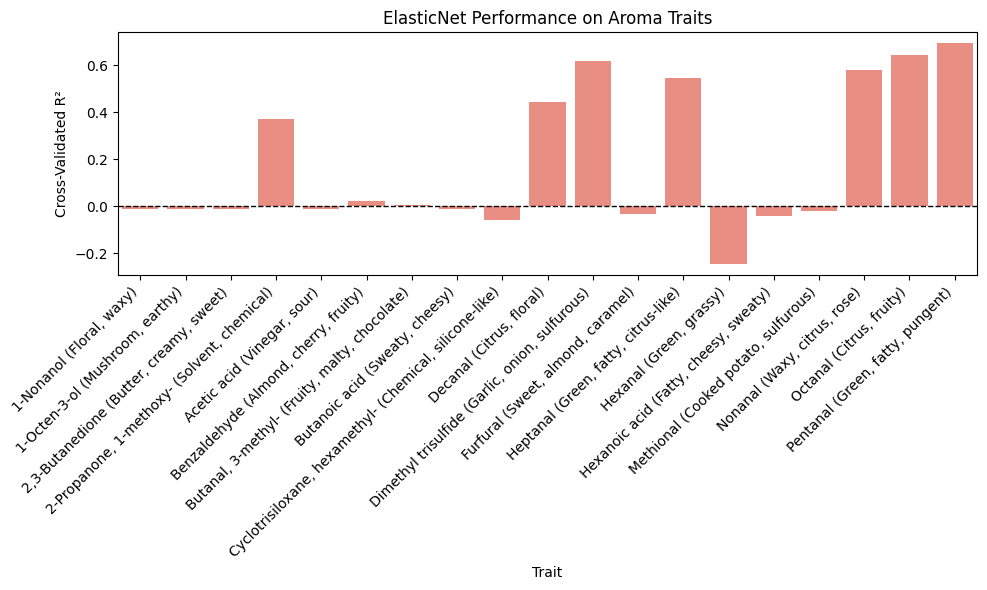

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df_enet,
    x="Trait",
    y="CV_Best_R2",
    color="salmon"
)
plt.xticks(rotation=45, ha="right")
plt.title("ElasticNet Performance on Aroma Traits")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


# ElasticNet + remove outliers


[Modeling - ElasticNet] Trait: 1-Nonanol (Floral, waxy)


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6670758.481867263, tolerance: 1299848.0548666385
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\fatemehm\AppData\Local\Programs\Python\Py


[Modeling - ElasticNet] Trait: 1-Octen-3-ol (Mushroom, earthy)


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec


[Modeling - ElasticNet] Trait: 2,3-Butanedione (Butter, creamy, sweet)


...

c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.031e+11, tolerance: 3.376e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.904e+10, tolerance: 3.376e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec


[Modeling - ElasticNet] Trait: Pentanal (Green, fatty, pungent)


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.505e+10, tolerance: 7.010e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.530e+10, tolerance: 8.613e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, chec


 ElasticNet results saved to elasticnet_regression_metrics_all_traits_no_outliers.csv


,Trait,n_SNPs,Best_alpha,Best_l1_ratio,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
1,"1-Octen-3-ol (Mushroom, earthy)",90,10.0,0.1,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00
2,"2,3-Butanedione (Butter, creamy, sweet)",90,10.0,0.1,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00
17,"Octanal (Citrus, fruity)",234,10.0,0.9,0.591479,0.929565,3.531430e+10,1.879210e+05,1.556163e+05
10,"Dimethyl trisulfide (Garlic, onion, sulfurous)",220,10.0,0.9,0.578859,0.914102,4.619600e+10,2.149326e+05,1.715281e+05
12,"Heptanal (Green, fatty, citrus-like)",306,10.0,0.9,0.556552,0.962322,5.496875e+09,7.414092e+04,5.281797e+04
16,"Nonanal (Waxy, citrus, rose)",152,10.0,0.5,0.556097,0.761845,1.446513e+13,3.803305e+06,3.004833e+06
3,"2-Propanone, 1-methoxy- (Solvent, chemical)",132,1.0,0.1,0.538381,0.838913,6.637637e+12,2.576361e+06,2.082707e+06
18,"Pentanal (Green, fatty, pungent)",174,10.0,0.9,0.522336,0.949763,5.565349e+10,2.359099e+05,1.721655e+05
9,"Decanal (Citrus, floral)",25,1.0,0.5,0.455463,0.694276,2.423795e+12,1.556854e+06,1.288226e+06
8,"Cyclotrisiloxane, hexamethyl- (Chemical, silic...",176,10.0,0.5,0.124822,0.538867,4.114040e+12,2.028310e+06,1.663203e+06


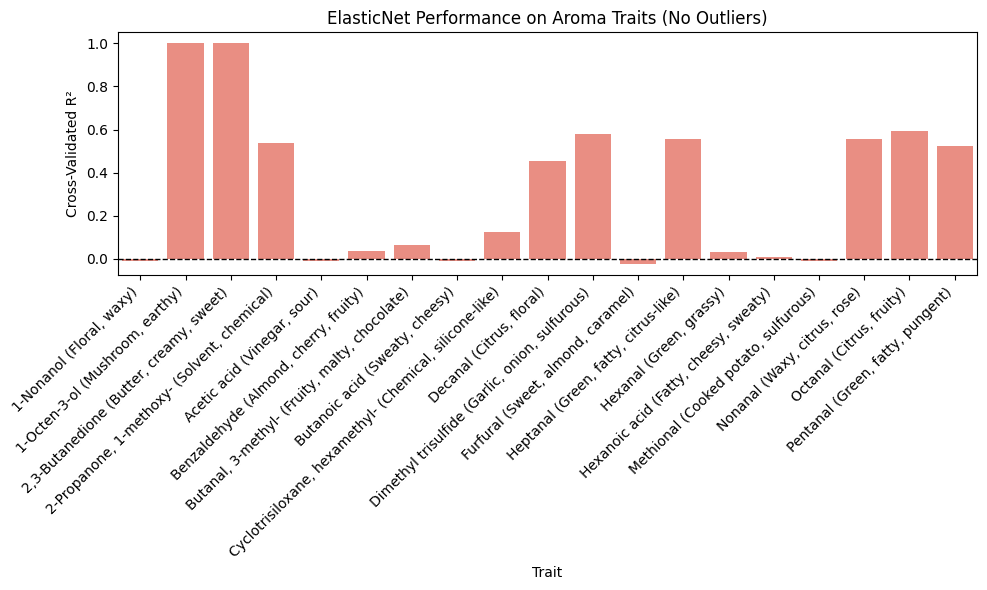

In [ ]:

cv = KFold(n_splits=5, shuffle=True, random_state=42)

#  Evaluation helper
def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

#  Load GWAS results + remove outliers
gwas_all = pd.read_csv("gwas_aroma_all_traits.csv")

# Drop outliers
outliers = ["INNOVATOR", "LADY CLAIRE"]
df_aroma = merged_snp_aroma.drop(index=[o for o in outliers if o in merged_snp_aroma.index])

results_enet = []

# loop over traits
for trait in gwas_all["Trait"].unique():
    print(f"\n[Modeling - ElasticNet] Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs for modeling.")
        continue

    # SNP matrix (without outliers)
    X = df_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # standardize + get target (without outliers)
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = df_aroma[trait].astype(float).values

    # ElasticNetCV

    enet_model = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=[0.01, 0.1, 1.0, 10.0],
        cv=cv,
        random_state=42,
        max_iter=5000
    )
    enet_model.fit(X_scaled, y)
    y_pred_enet = enet_model.predict(X_scaled)

    enet_metrics = evaluate_regression(y, y_pred_enet)
    enet_cv_r2 = np.mean(cross_val_score(enet_model, X_scaled, y, cv=cv, scoring="r2"))

    results_enet.append({
        "Trait": trait,
        "n_SNPs": X_pruned.shape[1],
        "Best_alpha": enet_model.alpha_,
        "Best_l1_ratio": enet_model.l1_ratio_,
        "CV_Best_R2": enet_cv_r2,
        **enet_metrics
    })


results_df_enet = pd.DataFrame(results_enet)
results_df_enet.to_csv("elasticnet_regression_metrics_all_traits_no_outliers.csv", index=False)

print("\n ElasticNet results saved to elasticnet_regression_metrics_all_traits_no_outliers.csv")
display(results_df_enet.sort_values("CV_Best_R2", ascending=False).head(10))



# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df_enet,
    x="Trait",
    y="CV_Best_R2",
    color="salmon"
)
plt.xticks(rotation=45, ha="right")
plt.title("ElasticNet Performance on Aroma Traits (No Outliers)")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


# Gwas per trait + KRR model + with outlier

In [ ]:

from sklearn.metrics import (
    make_scorer, r2_score, mean_squared_error,
    mean_absolute_error
)
#  Config

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100, 1000],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1, 10]
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)


#  Evaluation helper
def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


#  Load GWAS results

gwas_all = pd.read_csv("gwas_aroma_all_traits.csv")

results = []

# loop over traits
for trait in gwas_all["Trait"].unique():
    print(f"\n[Modeling] Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs for modeling.")
        continue

    # SNP matrix
    X = merged_snp_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # standardize + get target
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = merged_snp_aroma[trait].astype(float).values

    # grid search KRR
    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid,
        cv=cv,
        scoring=make_scorer(r2_score),
        n_jobs=-1
    )
    grid.fit(X_scaled, y)

    # best model prediction
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_scaled)

    # evaluate
    metrics = evaluate_regression(y, y_pred)

    # append results (important!)
    results.append({
        "Trait": trait,
        "n_SNPs": X_pruned.shape[1],
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_Best_R2": grid.best_score_,
        **metrics
    })


results_df = pd.DataFrame(results)
results_df.to_csv("final_models_with_metrics_all_traits.csv", index=False)

print("\n Modeling results saved to final_models_with_metrics_all_traits.csv")
display(results_df.sort_values("CV_Best_R2", ascending=False).head(10))



[Modeling] Trait: 1-Nonanol (Floral, waxy)

[Modeling] Trait: 1-Octen-3-ol (Mushroom, earthy)

[Modeling] Trait: 2,3-Butanedione (Butter, creamy, sweet)

[Modeling] Trait: 2-Propanone, 1-methoxy- (Solvent, chemical)

[Modeling] Trait: Acetic acid (Vinegar, sour)

[Modeling] Trait: Benzaldehyde (Almond, cherry, fruity)

[Modeling] Trait: Butanal, 3-methyl- (Fruity, malty, chocolate)

[Modeling] Trait: Butanoic acid (Sweaty, cheesy)

[Modeling] Trait: Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)

[Modeling] Trait: Decanal (Citrus, floral)

[Modeling] Trait: Dimethyl trisulfide (Garlic, onion, sulfurous)

[Modeling] Trait: Furfural (Sweet, almond, caramel)

[Modeling] Trait: Heptanal (Green, fatty, citrus-like)

[Modeling] Trait: Hexanal (Green, grassy)

[Modeling] Trait: Hexanoic acid (Fatty, cheesy, sweaty)

[Modeling] Trait: Methional (Cooked potato, sulfurous)

[Modeling] Trait: Nonanal (Waxy, citrus, rose)

[Modeling] Trait: Octanal (Citrus, fruity)

[Modeling] Trait: Pen

,Trait,n_SNPs,Best_alpha,Best_gamma,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
0,"1-Nonanol (Floral, waxy)",51,0.01,1.0000,0.788889,0.999901,1.374140e+04,1.172237e+02,1.209070e+01
1,"1-Octen-3-ol (Mushroom, earthy)",87,0.01,1.0000,0.788889,0.999901,1.346489e+04,1.160383e+02,1.196844e+01
2,"2,3-Butanedione (Butter, creamy, sweet)",87,0.01,1.0000,0.788889,0.999901,8.083050e+03,8.990578e+01,9.273073e+00
4,"Acetic acid (Vinegar, sour)",1,0.01,10.0000,0.788889,0.999901,7.071945e+06,2.659313e+03,2.742872e+02
7,"Butanoic acid (Sweaty, cheesy)",1,0.01,10.0000,0.788889,0.999901,7.489473e+01,8.654174e+00,8.926099e-01
18,"Pentanal (Green, fatty, pungent)",175,0.01,0.0001,0.685272,0.970456,3.243279e+10,1.800911e+05,1.332934e+05
17,"Octanal (Citrus, fruity)",233,0.01,0.0001,0.672368,0.959017,2.032931e+10,1.425809e+05,1.183354e+05
10,"Dimethyl trisulfide (Garlic, onion, sulfurous)",223,0.10,0.0001,0.603805,0.790249,1.143133e+11,3.381025e+05,2.671764e+05
15,"Methional (Cooked potato, sulfurous)",3,0.01,10.0000,0.577778,0.999900,3.116959e+03,5.582973e+01,8.055269e+00
16,"Nonanal (Waxy, citrus, rose)",152,0.01,0.0001,0.567859,0.913294,5.236264e+12,2.288288e+06,1.816086e+06


# Barplot for KRR model evaluation

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_17760\2891256439.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


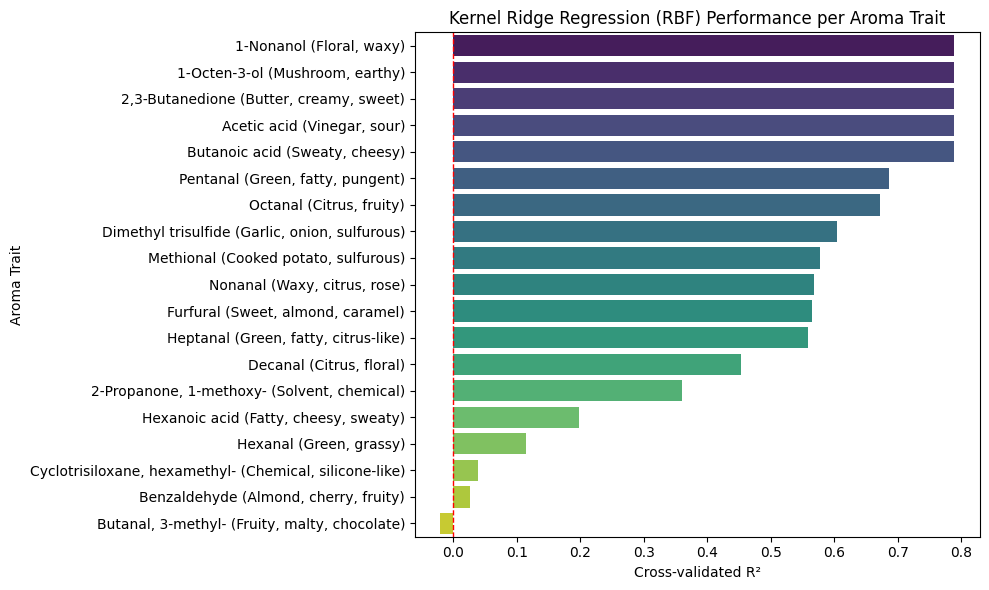

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df.sort_values("CV_Best_R2", ascending=False),
    x="CV_Best_R2", y="Trait", palette="viridis"
)
plt.axvline(0, color="red", linestyle="--", lw=1)  # mark zero baseline
plt.xlabel("Cross-validated R²")
plt.ylabel("Aroma Trait")
plt.title("Kernel Ridge Regression (RBF) Performance per Aroma Trait")
plt.tight_layout()
plt.show()


# KRR+ removing outliers


[Modeling - KRR] Trait: 1-Nonanol (Floral, waxy)

[Modeling - KRR] Trait: 1-Octen-3-ol (Mushroom, earthy)

[Modeling - KRR] Trait: 2,3-Butanedione (Butter, creamy, sweet)

[Modeling - KRR] Trait: Acetic acid (Vinegar, sour)

[Modeling - KRR] Trait: Benzaldehyde (Almond, cherry, fruity)

[Modeling - KRR] Trait: Butanal, 3-methyl- (Fruity, malty, chocolate)

[Modeling - KRR] Trait: Butanoic acid (Sweaty, cheesy)

[Modeling - KRR] Trait: Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)

[Modeling - KRR] Trait: Decanal (Citrus, floral)

[Modeling - KRR] Trait: Dimethyl trisulfide (Garlic, onion, sulfurous)

[Modeling - KRR] Trait: Furfural (Sweet, almond, caramel)

[Modeling - KRR] Trait: Heptanal (Green, fatty, citrus-like)

[Modeling - KRR] Trait: Hexanal (Green, grassy)

[Modeling - KRR] Trait: Hexanoic acid (Fatty, cheesy, sweaty)

[Modeling - KRR] Trait: Methional (Cooked potato, sulfurous)

[Modeling - KRR] Trait: Nonanal (Waxy, citrus, rose)

[Modeling - KRR] Trait: Octanal 

,Trait,n_SNPs,Best_alpha,Best_gamma,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
1,"1-Octen-3-ol (Mushroom, earthy)",90,0.01,0.0001,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00
2,"2,3-Butanedione (Butter, creamy, sweet)",90,0.01,0.0001,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00
0,"1-Nonanol (Floral, waxy)",51,0.01,1.0000,0.788889,0.999901,1.388915e+04,1.178522e+02,1.222071e+01
6,"Butanoic acid (Sweaty, cheesy)",1,0.01,10.0000,0.788235,0.999901,7.570005e+01,8.700577e+00,9.022078e-01
3,"Acetic acid (Vinegar, sour)",1,0.01,10.0000,0.788235,0.999901,7.147987e+06,2.673572e+03,2.772365e+02
14,"Methional (Cooked potato, sulfurous)",2,0.01,10.0000,0.788235,0.999901,1.117487e+03,3.342884e+01,3.466409e+00
10,"Furfural (Sweet, almond, caramel)",3,0.01,10.0000,0.775188,0.999900,6.938555e+03,8.329799e+01,1.217439e+01
16,"Octanal (Citrus, fruity)",234,0.01,0.0001,0.608255,0.959405,2.035335e+10,1.426652e+05,1.180487e+05
9,"Dimethyl trisulfide (Garlic, onion, sulfurous)",220,0.01,0.0001,0.588752,0.947318,2.833226e+10,1.683219e+05,1.337884e+05
15,"Nonanal (Waxy, citrus, rose)",152,0.10,0.0001,0.564452,0.752208,1.505048e+13,3.879494e+06,3.066225e+06


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_9256\1401838232.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


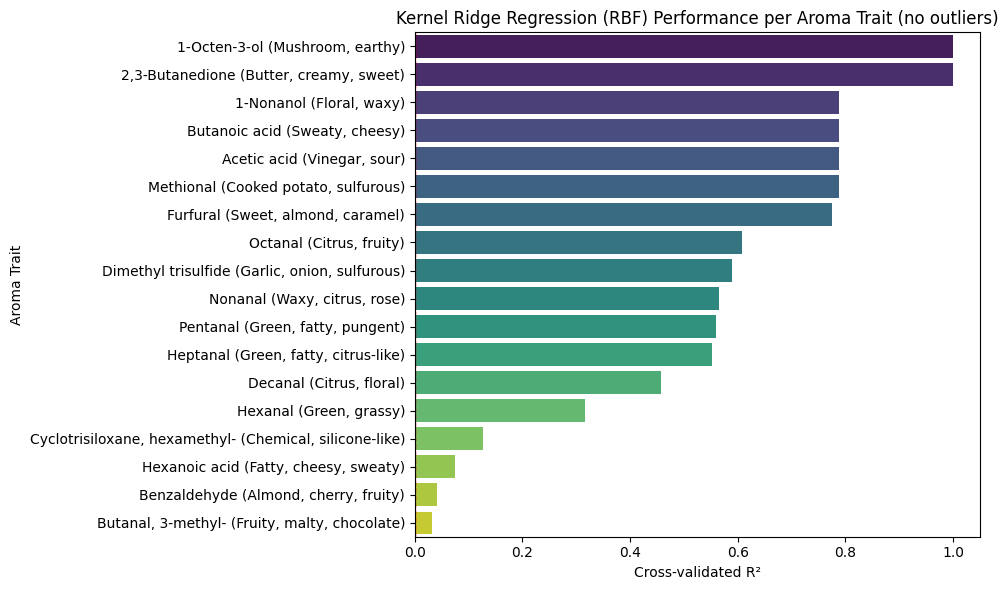

In [ ]:

from sklearn.metrics import (
    make_scorer, r2_score, mean_squared_error,
    mean_absolute_error
)

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100, 1000],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1, 10]
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)


# Evaluation helper

def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

#  Load GWAS results + remove outliers

gwas_all = pd.read_csv("gwas_aroma_all_traits.csv")

# Remove outliers from merged dataset
outliers = ["INNOVATOR", "LADY CLAIRE"]
df_aroma = merged_snp_aroma.drop(index=[o for o in outliers if o in merged_snp_aroma.index])

results = []

# loop over traits
for trait in gwas_all["Trait"].unique():
    print(f"\n[Modeling - KRR] Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs for modeling.")
        continue

    # SNP matrix (without outliers)
    X = df_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # standardize + get target (without outliers)
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = df_aroma[trait].astype(float).values

    # grid search KRR
    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid,
        cv=cv,
        scoring=make_scorer(r2_score),
        n_jobs=-1
    )
    grid.fit(X_scaled, y)

    # best model prediction
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_scaled)

    # evaluate
    metrics = evaluate_regression(y, y_pred)

    # append results
    results.append({
        "Trait": trait,
        "n_SNPs": X_pruned.shape[1],
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_Best_R2": grid.best_score_,
        **metrics
    })


#  Save modeling results

results_df = pd.DataFrame(results)
results_df.to_csv("final_krr_metrics_no_outliers.csv", index=False)

print("\n KRR results saved to final_krr_metrics_no_outliers.csv")
display(results_df.sort_values("CV_Best_R2", ascending=False).head(10))


plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df.sort_values("CV_Best_R2", ascending=False),
    x="CV_Best_R2", y="Trait", palette="viridis"
)
plt.axvline(0, color="red", linestyle="--", lw=1)  # mark zero baseline
plt.xlabel("Cross-validated R²")
plt.ylabel("Aroma Trait")
plt.title("Kernel Ridge Regression (RBF) Performance per Aroma Trait (no outliers)")
plt.tight_layout()
plt.show()



Cyclotrisiloxane and Benzaldehyde were among the most abundant aroma compounds, but they showed low genomic predictability, suggesting stronger environmental or non-additive effects compared to other trait

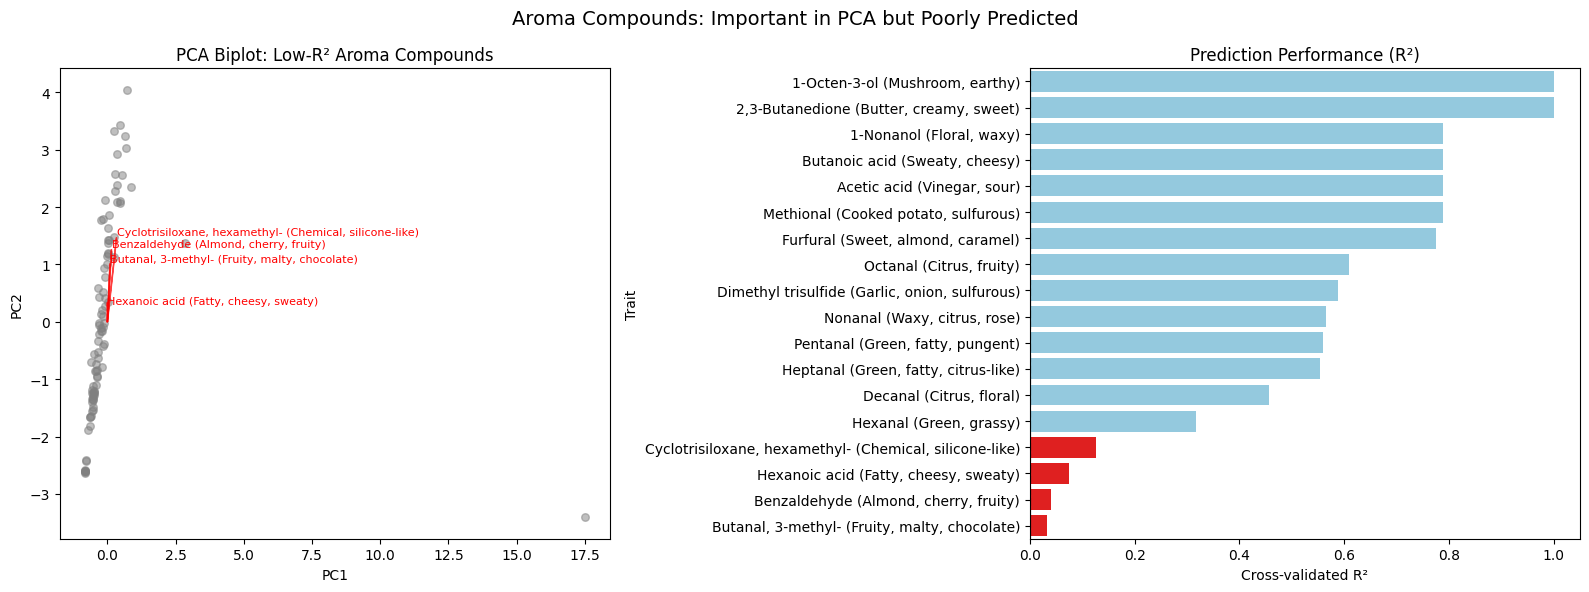

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ----------------------------
# PCA on aroma compounds
# ----------------------------
# Take only aroma trait columns from df_aroma (exclude SNPs and non-aroma metadata)
aroma_cols = [c for c in df_aroma.columns if c in results_df["Trait"].unique()]
X_aroma = df_aroma[aroma_cols].astype(float).fillna(0)

# Standardize
X_scaled = StandardScaler().fit_transform(X_aroma)

# PCA
pca = PCA(n_components=2, random_state=42)
scores_array = pca.fit_transform(X_scaled)

# Scores (samples × PCs)
scores = pd.DataFrame(scores_array, columns=["PC1", "PC2"], index=df_aroma.index)

# Loadings (traits × PCs)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=["PC1", "PC2"], 
    index=aroma_cols
)

# ----------------------------
# Plot PCA biplot + R²
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: PCA biplot for low-R² traits
axes[0].scatter(scores["PC1"], scores["PC2"], s=30, alpha=0.5, color="gray")
for trait, (x, y) in loadings[["PC1", "PC2"]].iterrows():
    if trait in low_r2_traits:
        axes[0].arrow(0, 0, x*3, y*3, color="red", alpha=0.7, width=0.01)
        axes[0].text(x*3.2, y*3.2, trait, fontsize=8, color="red")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA Biplot: Low-R² Aroma Compounds")

# Right: Model performance
sns.barplot(
    data=perf_df.sort_values("R2", ascending=False),
    y="Trait", x="R2",
    hue="Highlight", dodge=False,
    palette={True: "red", False: "skyblue"},
    ax=axes[1]
)
axes[1].axvline(0, color="k", linestyle="--")
axes[1].set_title("Prediction Performance (R²)")
axes[1].set_xlabel("Cross-validated R²")
axes[1].legend_.remove()

plt.suptitle("Aroma Compounds: Important in PCA but Poorly Predicted", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.kernel_ridge import KernelRidge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# ----------------------------
# Traits with low R²
# ----------------------------
low_r2_traits = [
    "Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)",
    "Benzaldehyde (Almond, cherry, fruity)",
    "Hexanoic acid (Fatty, cheesy, sweaty)",
    "Butanal, 3-methyl- (Fruity, malty, chocolate)"
]

# GWAS results file
gwas_all = pd.read_csv("gwas_aroma_all_traits.csv")

# Outlier-free dataset
outliers = ["INNOVATOR", "LADY CLAIRE"]
df_aroma = merged_snp_aroma.drop(index=[o for o in outliers if o in merged_snp_aroma.index])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ----------------------------
# Hyperparameter grids
# ----------------------------
param_grid_krr = {
    "alpha": [0.01, 0.1, 1, 10, 100],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1]
}

param_grid_xgb = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.1, 0.3],
    "n_estimators": [100, 200, 500],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

results = []

# ----------------------------
# Loop over low-R² traits
# ----------------------------
for trait in low_r2_traits:
    print(f"\n🔎 Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]
    
    # top SNPs for this trait
    top_snps = gwas_df.sort_values("p_fdr").head(1200)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs found.")
        continue

    # SNP matrix
    X = df_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)  # LD pruning
    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # Standardize
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = np.log1p(df_aroma[trait].astype(float).values)


    # ------------------------
    # Kernel Ridge Regression
    # ------------------------
    grid_krr = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid_krr,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )
    grid_krr.fit(X_scaled, y)
    best_krr = grid_krr.best_estimator_
    y_pred_krr = best_krr.predict(X_scaled)
    r2_krr = r2_score(y, y_pred_krr)

    results.append({
        "Trait": trait,
        "Model": "KRR-RBF",
        "Best_params": grid_krr.best_params_,
        "CV_Best_R2": grid_krr.best_score_,
        "In_sample_R2": r2_krr
    })

    # ------------------------
    # XGBoost Regression
    # ------------------------
    grid_xgb = GridSearchCV(
        XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
        param_grid_xgb,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )
    grid_xgb.fit(X_scaled, y)
    best_xgb = grid_xgb.best_estimator_
    y_pred_xgb = best_xgb.predict(X_scaled)
    r2_xgb = r2_score(y, y_pred_xgb)

    results.append({
        "Trait": trait,
        "Model": "XGBoost",
        "Best_params": grid_xgb.best_params_,
        "CV_Best_R2": grid_xgb.best_score_,
        "In_sample_R2": r2_xgb
    })

# ----------------------------
# Collect results
# ----------------------------
results_df = pd.DataFrame(results)
print("\n=== Focused results on low-R² compounds ===")
display(results_df.sort_values(["Trait", "CV_Best_R2"], ascending=[True, False]))



🔎 Trait: Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)

🔎 Trait: Benzaldehyde (Almond, cherry, fruity)

🔎 Trait: Hexanoic acid (Fatty, cheesy, sweaty)

🔎 Trait: Butanal, 3-methyl- (Fruity, malty, chocolate)

=== Focused results on low-R² compounds ===


,Trait,Model,Best_params,CV_Best_R2,In_sample_R2
2,"Benzaldehyde (Almond, cherry, fruity)",KRR-RBF,"{'alpha': 0.01, 'gamma': 0.0001}",0.031718,0.900662
3,"Benzaldehyde (Almond, cherry, fruity)",XGBoost,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",-0.060829,0.563383
7,"Butanal, 3-methyl- (Fruity, malty, chocolate)",XGBoost,"{'colsample_bytree': 0.7, 'learning_rate': 0.3...",-0.226158,0.005928
6,"Butanal, 3-methyl- (Fruity, malty, chocolate)",KRR-RBF,"{'alpha': 0.01, 'gamma': 0.0001}",-0.252812,0.005265
0,"Cyclotrisiloxane, hexamethyl- (Chemical, silic...",KRR-RBF,"{'alpha': 0.1, 'gamma': 0.0001}",0.105666,0.504828
1,"Cyclotrisiloxane, hexamethyl- (Chemical, silic...",XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.071398,0.999886
5,"Hexanoic acid (Fatty, cheesy, sweaty)",XGBoost,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.041125,0.334231
4,"Hexanoic acid (Fatty, cheesy, sweaty)",KRR-RBF,"{'alpha': 0.1, 'gamma': 0.001}",0.039931,0.263229



🔎 SNP importance for: Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)
             SNP  SHAP_importance
135    GEN__2830         0.209652
48   GEN__479985         0.181440
2        GEN__58         0.152781
44      GEN__654         0.138637
150    GEN__3296         0.103799
97     GEN__1585         0.097360
20      GEN__261         0.090194
139    GEN__2768         0.086071
105    GEN__1780         0.069098
84     GEN__1271         0.064012
Permutation top SNPs:
             SNP  PermutationImportance
135    GEN__2830               0.079111
48   GEN__479985               0.059840
2        GEN__58               0.059516
43      GEN__653               0.055729
44      GEN__654               0.053974
150    GEN__3296               0.031116
20      GEN__261               0.031001
97     GEN__1585               0.023607
105    GEN__1780               0.021314
107    GEN__1820               0.018567


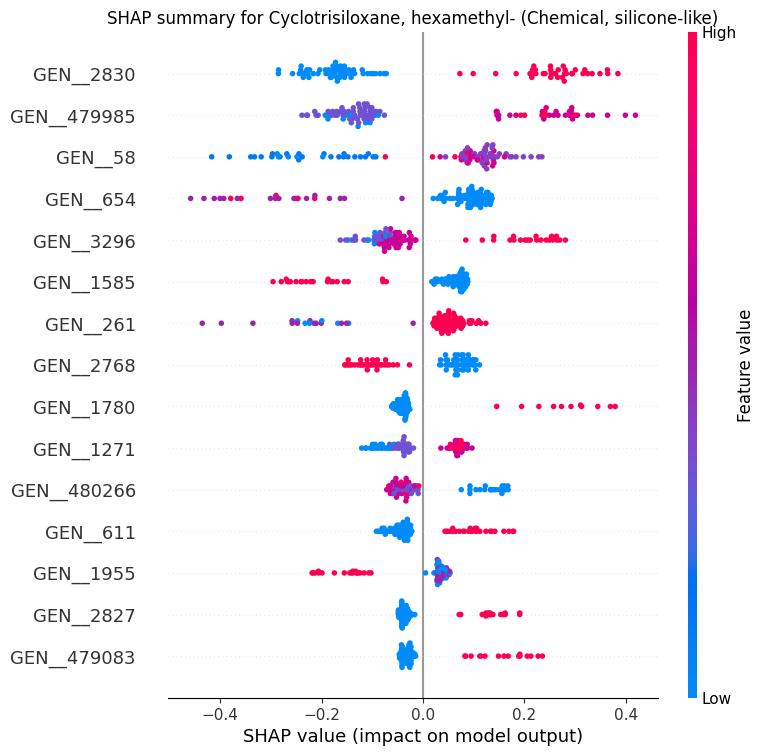


🔎 SNP importance for: Benzaldehyde (Almond, cherry, fruity)
             SNP  SHAP_importance
54      GEN__623         0.520205
198    GEN__2831         0.401902
23      GEN__187         0.326244
183    GEN__2644         0.212304
208  GEN__564122         0.211905
125  GEN__382996         0.183945
116  GEN__382999         0.165193
165  GEN__394236         0.143243
88   GEN__564649         0.139954
83      GEN__866         0.138395
Permutation top SNPs:
             SNP  PermutationImportance
54      GEN__623               0.131392
198    GEN__2831               0.090762
23      GEN__187               0.081034
88   GEN__564649               0.039722
208  GEN__564122               0.037223
125  GEN__382996               0.028093
183    GEN__2644               0.027704
196    GEN__2720               0.017912
116  GEN__382999               0.014334
224  GEN__564060               0.012930


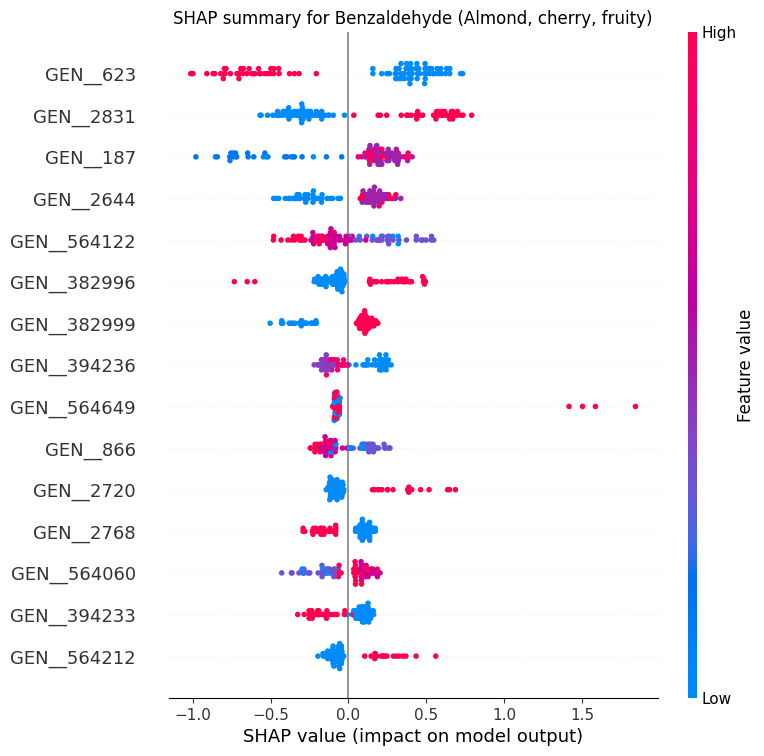


🔎 SNP importance for: Hexanoic acid (Fatty, cheesy, sweaty)
           SNP  SHAP_importance
0  GEN__191068         0.377223
4  GEN__151428         0.375736
3  GEN__561510         0.371941
1   GEN__26007         0.291842
2  GEN__560372         0.049005
Permutation top SNPs:
           SNP  PermutationImportance
3  GEN__561510               0.230446
4  GEN__151428               0.212050
0  GEN__191068               0.210861
1   GEN__26007               0.172083
2  GEN__560372               0.008057


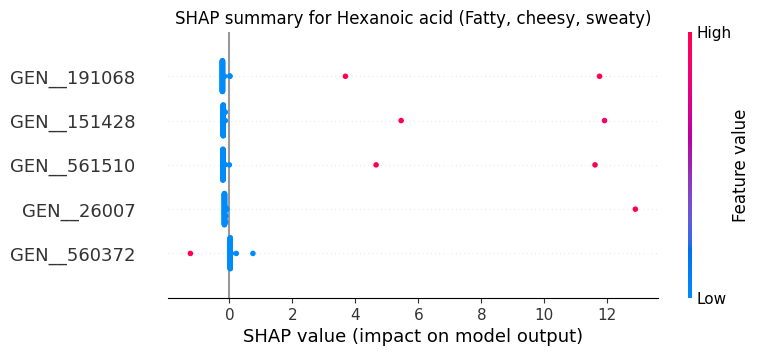


🔎 SNP importance for: Butanal, 3-methyl- (Fruity, malty, chocolate)
           SNP  SHAP_importance
0  GEN__152879         0.101799
Permutation top SNPs:
           SNP  PermutationImportance
0  GEN__152879               0.016282


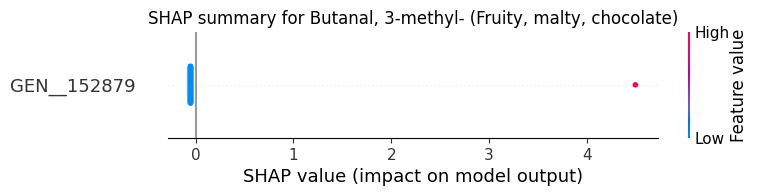

In [ ]:
import shap
from sklearn.inspection import permutation_importance

# Storage
feature_importances = []

# Loop again for low-R² traits
for trait in low_r2_traits:
    print(f"\n🔎 SNP importance for: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]
    top_snps = gwas_df.sort_values("p_fdr").head(1200)["SNP"].tolist()
    if not top_snps:
        continue

    X = df_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)
    if X_pruned.shape[1] == 0:
        continue

    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = np.log1p(df_aroma[trait].astype(float).values)

    # --- Fit XGBoost (best for feature importance tools) ---
    best_xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9
    )
    best_xgb.fit(X_scaled, y)

    # --- SHAP values ---
    explainer = shap.TreeExplainer(best_xgb)
    shap_values = explainer.shap_values(X_scaled)

    # Mean absolute SHAP per SNP
    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({
        "SNP": X_pruned.columns,
        "SHAP_importance": shap_importance
    }).sort_values("SHAP_importance", ascending=False)

    print(shap_df.head(10))  # top SNPs
    feature_importances.append((trait, shap_df))

    # --- Optional: permutation importance ---
    perm = permutation_importance(best_xgb, X_scaled, y, n_repeats=10, random_state=42, n_jobs=-1)
    perm_df = pd.DataFrame({
        "SNP": X_pruned.columns,
        "PermutationImportance": perm.importances_mean
    }).sort_values("PermutationImportance", ascending=False)

    print("Permutation top SNPs:")
    print(perm_df.head(10))

    # --- SHAP summary plot ---
    shap.summary_plot(shap_values, X_scaled, feature_names=X_pruned.columns,
                      show=False, max_display=15)
    plt.title(f"SHAP summary for {trait}")
    plt.show()


Although prediction accuracy for Cyclotrisiloxane, Benzaldehyde, Hexanoic acid, and Butanal-3-methyl was low (R² ≈ 0), SHAP analysis highlighted candidate SNPs (e.g., GEN__2830, GEN__479985; GEN__623, GEN__2831; GEN__191068, GEN__151428; GEN__152879). This indicates that despite weak predictability and strong environmental effects, certain loci may still influence these traits, providing targets for follow-up validation.”

Using SHAP values, we can interpret how individual SNPs influence a compound, even in cases where the overall predictive performance was low

“In addition to identifying which genetic markers are most influential, SHAP values also allow us to interpret how changes in allele state (reference, heterozygous, or alternative) affect the abundance of a specific compound.”

# Gwas per trait +Non-linear Models   + with outlier


[Modeling - Nonlinear] Trait: 1-Nonanol (Floral, waxy)

[Modeling - Nonlinear] Trait: 1-Octen-3-ol (Mushroom, earthy)

[Modeling - Nonlinear] Trait: 2,3-Butanedione (Butter, creamy, sweet)

[Modeling - Nonlinear] Trait: Acetic acid (Vinegar, sour)

[Modeling - Nonlinear] Trait: Benzaldehyde (Almond, cherry, fruity)

[Modeling - Nonlinear] Trait: Butanal, 3-methyl- (Fruity, malty, chocolate)

[Modeling - Nonlinear] Trait: Butanoic acid (Sweaty, cheesy)

[Modeling - Nonlinear] Trait: Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)

[Modeling - Nonlinear] Trait: Decanal (Citrus, floral)

[Modeling - Nonlinear] Trait: Dimethyl trisulfide (Garlic, onion, sulfurous)

[Modeling - Nonlinear] Trait: Furfural (Sweet, almond, caramel)

[Modeling - Nonlinear] Trait: Heptanal (Green, fatty, citrus-like)

[Modeling - Nonlinear] Trait: Hexanal (Green, grassy)

[Modeling - Nonlinear] Trait: Hexanoic acid (Fatty, cheesy, sweaty)

[Modeling - Nonlinear] Trait: Methional (Cooked potato, sulfurou

,Trait,Model,n_SNPs,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
19,"Butanoic acid (Sweaty, cheesy)",RandomForest,1,0.788889,0.872620,9.628324e+04,3.102954e+02,3.200453e+01
10,"Acetic acid (Vinegar, sour)",RandomForest,1,0.788889,0.872620,9.091558e+09,9.534966e+04,9.834567e+03
31,"Furfural (Sweet, almond, caramel)",RandomForest,4,0.565536,0.917319,8.460615e+06,2.908714e+03,5.067507e+02
52,"Pentanal (Green, fatty, pungent)",RandomForest,175,0.386549,0.916829,9.130147e+10,3.021613e+05,1.686071e+05
46,"Nonanal (Waxy, citrus, rose)",RandomForest,152,0.362412,0.917587,4.977047e+12,2.230930e+06,1.652094e+06
53,"Pentanal (Green, fatty, pungent)",XGBoost,175,0.339256,1.000000,8.915905e+03,9.442407e+01,6.818353e+01
49,"Octanal (Citrus, fruity)",RandomForest,233,0.338279,0.917939,4.070612e+10,2.017576e+05,1.524357e+05
28,"Dimethyl trisulfide (Garlic, onion, sulfurous)",RandomForest,223,0.334874,0.906687,5.085523e+10,2.255111e+05,1.791692e+05
25,"Decanal (Citrus, floral)",RandomForest,25,0.320793,0.909600,7.164540e+11,8.464360e+05,6.815046e+05
50,"Octanal (Citrus, fruity)",XGBoost,233,0.303732,1.000000,3.434731e+03,5.860658e+01,4.369854e+01


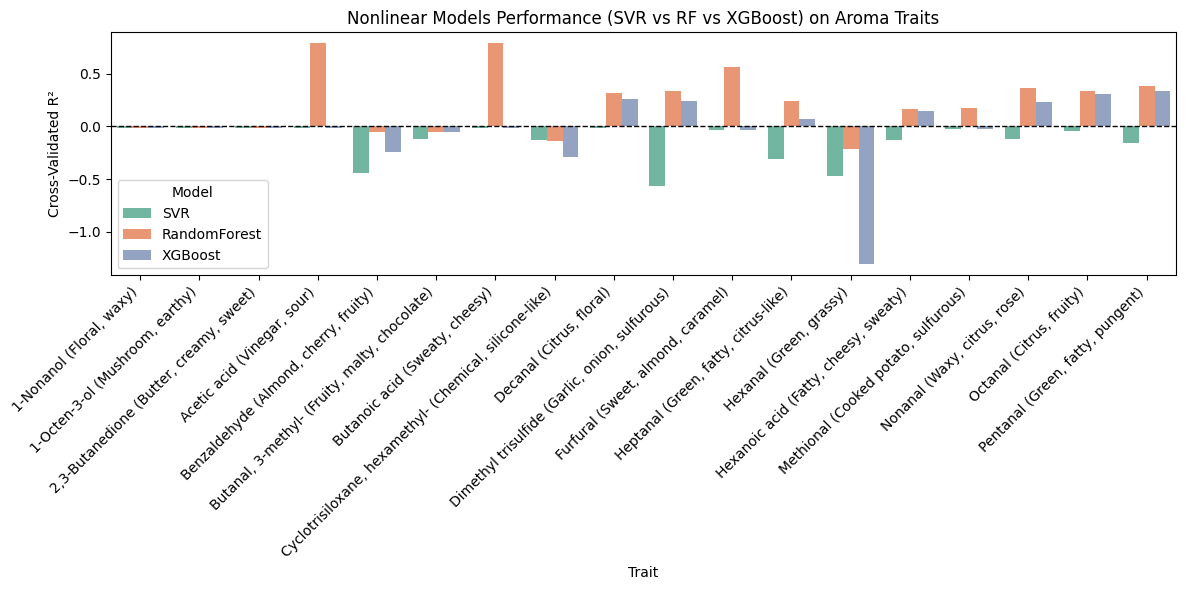

In [ ]:


cv = KFold(n_splits=5, shuffle=True, random_state=42)


# Evaluation helper
def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }



# Define models
nonlinear_models = {
    "SVR": SVR(kernel="rbf", C=10, gamma=0.1),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.1,
        max_depth=4, random_state=42, n_jobs=-1
    )
}



# Run per trait
results_nonlinear = []

for trait in gwas_all["Trait"].unique():
    print(f"\n[Modeling - Nonlinear] Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs for modeling.")
        continue

    # SNP matrix
    X = merged_snp_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # standardize + get target
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = merged_snp_aroma[trait].astype(float).values

    # loop over models
    for name, model in nonlinear_models.items():
        model.fit(X_scaled, y)
        y_pred = model.predict(X_scaled)

        metrics = evaluate_regression(y, y_pred)
        cv_r2 = np.mean(cross_val_score(model, X_scaled, y, cv=cv, scoring="r2"))

        results_nonlinear.append({
            "Trait": trait,
            "Model": name,
            "n_SNPs": X_pruned.shape[1],
            "CV_Best_R2": cv_r2,
            **metrics
        })



#  Save results
results_df_nonlinear = pd.DataFrame(results_nonlinear)
results_df_nonlinear.to_csv("nonlinear_models_metrics_all_traits.csv", index=False)
print("\nNonlinear modeling results saved to nonlinear_models_metrics_all_traits.csv")
display(results_df_nonlinear.sort_values("CV_Best_R2", ascending=False).head(10))



# Visualization: Comparison
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_nonlinear,
    x="Trait",
    y="CV_Best_R2",
    hue="Model",
    palette="Set2"
)
plt.xticks(rotation=45, ha="right")
plt.title("Nonlinear Models Performance (SVR vs RF vs XGBoost) on Aroma Traits")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()



[Modeling - Nonlinear, no outliers] Trait: 1-Nonanol (Floral, waxy)

[Modeling - Nonlinear, no outliers] Trait: 1-Octen-3-ol (Mushroom, earthy)

[Modeling - Nonlinear, no outliers] Trait: 2,3-Butanedione (Butter, creamy, sweet)

[Modeling - Nonlinear, no outliers] Trait: Acetic acid (Vinegar, sour)

[Modeling - Nonlinear, no outliers] Trait: Benzaldehyde (Almond, cherry, fruity)

[Modeling - Nonlinear, no outliers] Trait: Butanal, 3-methyl- (Fruity, malty, chocolate)

[Modeling - Nonlinear, no outliers] Trait: Butanoic acid (Sweaty, cheesy)

[Modeling - Nonlinear, no outliers] Trait: Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)

[Modeling - Nonlinear, no outliers] Trait: Decanal (Citrus, floral)

[Modeling - Nonlinear, no outliers] Trait: Dimethyl trisulfide (Garlic, onion, sulfurous)

[Modeling - Nonlinear, no outliers] Trait: Furfural (Sweet, almond, caramel)

[Modeling - Nonlinear, no outliers] Trait: Heptanal (Green, fatty, citrus-like)

[Modeling - Nonlinear, no outlie

,Trait,Model,n_SNPs,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
4,"1-Octen-3-ol (Mushroom, earthy)",RandomForest,90,1.000000,1.000000,0.000000e+00,0.000000,0.000000
3,"1-Octen-3-ol (Mushroom, earthy)",SVR,90,1.000000,1.000000,0.000000e+00,0.000000,0.000000
5,"1-Octen-3-ol (Mushroom, earthy)",XGBoost,90,1.000000,1.000000,0.000000e+00,0.000000,0.000000
8,"2,3-Butanedione (Butter, creamy, sweet)",XGBoost,90,1.000000,1.000000,0.000000e+00,0.000000,0.000000
7,"2,3-Butanedione (Butter, creamy, sweet)",RandomForest,90,1.000000,1.000000,0.000000e+00,0.000000,0.000000
6,"2,3-Butanedione (Butter, creamy, sweet)",SVR,90,1.000000,1.000000,0.000000e+00,0.000000,0.000000
19,"Butanoic acid (Sweaty, cheesy)",RandomForest,1,0.788235,0.883143,8.926819e+04,298.777825,30.981817
10,"Acetic acid (Vinegar, sour)",RandomForest,1,0.788235,0.883143,8.429161e+09,91810.461471,9520.301362
43,"Methional (Cooked potato, sulfurous)",RandomForest,2,0.788235,0.883143,1.317781e+06,1147.946402,119.036497
31,"Furfural (Sweet, almond, caramel)",RandomForest,3,0.775188,0.947979,3.603435e+06,1898.271603,274.851753


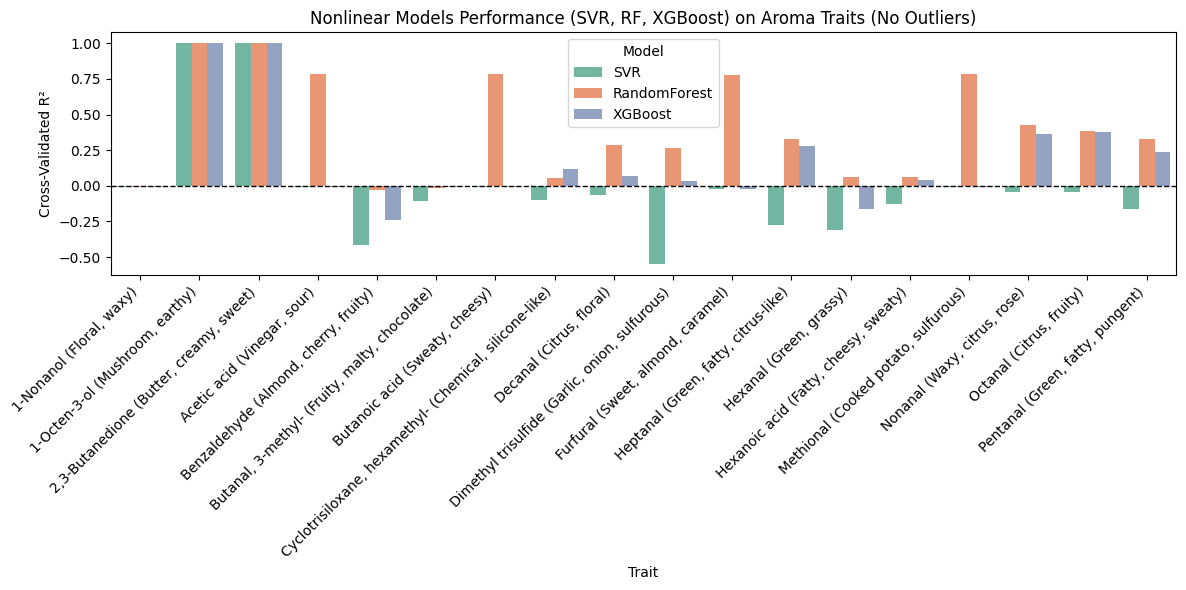

In [ ]:

from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error
)


#  Config
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Remove outliers
outliers = ["INNOVATOR", "LADY CLAIRE"]
df_aroma = merged_snp_aroma.drop(index=[o for o in outliers if o in merged_snp_aroma.index])

# Evaluation helper
def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


#  Define nonlinear models

nonlinear_models = {
    "SVR": SVR(kernel="rbf", C=10, gamma=0.1),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.1,
        max_depth=4, random_state=42, n_jobs=-1
    )
}

#  Run per trait
results_nonlinear = []

for trait in gwas_all["Trait"].unique():
    print(f"\n[Modeling - Nonlinear, no outliers] Trait: {trait}")
    gwas_df = gwas_all[gwas_all["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        print("  No SNPs for modeling.")
        continue

    # SNP matrix without outliers
    X = df_aroma[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        print("  No SNPs after pruning.")
        continue

    # standardize + get target without outliers
    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = df_aroma[trait].astype(float).values

    # loop over models
    for name, model in nonlinear_models.items():
        model.fit(X_scaled, y)
        y_pred = model.predict(X_scaled)

        metrics = evaluate_regression(y, y_pred)
        cv_r2 = np.mean(cross_val_score(model, X_scaled, y, cv=cv, scoring="r2"))

        results_nonlinear.append({
            "Trait": trait,
            "Model": name,
            "n_SNPs": X_pruned.shape[1],
            "CV_Best_R2": cv_r2,
            **metrics
        })


#  Save results

results_df_nonlinear = pd.DataFrame(results_nonlinear)
results_df_nonlinear.to_csv("nonlinear_models_metrics_no_outliers.csv", index=False)

print("\n Nonlinear modeling results saved to nonlinear_models_metrics_no_outliers.csv")
display(results_df_nonlinear.sort_values("CV_Best_R2", ascending=False).head(10))



plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_nonlinear,
    x="Trait",
    y="CV_Best_R2",
    hue="Model",
    palette="Set2"
)
plt.xticks(rotation=45, ha="right")
plt.title("Nonlinear Models Performance (SVR, RF, XGBoost) on Aroma Traits (No Outliers)")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


# GWas per trait - all models


=== Model Comparison (Mean ± Std of CV R²) ===


,Model,Outliers,Mean_CV_R2,Std_CV_R2
2,KernelRidge_RBF,With Outliers,0.491898,0.286601
6,RandomForest,With Outliers,0.221428,0.294819
0,ElasticNet,With Outliers,0.182037,0.306056
8,Ridge,With Outliers,0.015582,0.391681
4,LinearRegression,With Outliers,-0.009756,0.415122
12,XGBoost,With Outliers,-0.022620,0.365351
10,SVR_RBF,With Outliers,-0.145154,0.179014
3,KernelRidge_RBF,Without Outliers,0.546478,0.305783
7,RandomForest,Without Outliers,0.404588,0.362001
1,ElasticNet,Without Outliers,0.315647,0.349951



--- With Outliers ---


,Model,Outliers,Mean_CV_R2,Std_CV_R2
2,KernelRidge_RBF,With Outliers,0.491898,0.286601
6,RandomForest,With Outliers,0.221428,0.294819
0,ElasticNet,With Outliers,0.182037,0.306056
8,Ridge,With Outliers,0.015582,0.391681
4,LinearRegression,With Outliers,-0.009756,0.415122
12,XGBoost,With Outliers,-0.022620,0.365351
10,SVR_RBF,With Outliers,-0.145154,0.179014



--- Without Outliers ---


,Model,Outliers,Mean_CV_R2,Std_CV_R2
3,KernelRidge_RBF,Without Outliers,0.546478,0.305783
7,RandomForest,Without Outliers,0.404588,0.362001
1,ElasticNet,Without Outliers,0.315647,0.349951
9,Ridge,Without Outliers,0.181540,0.390537
13,XGBoost,Without Outliers,0.168537,0.342847
5,LinearRegression,Without Outliers,0.161338,0.403201
11,SVR_RBF,Without Outliers,-0.015408,0.399929


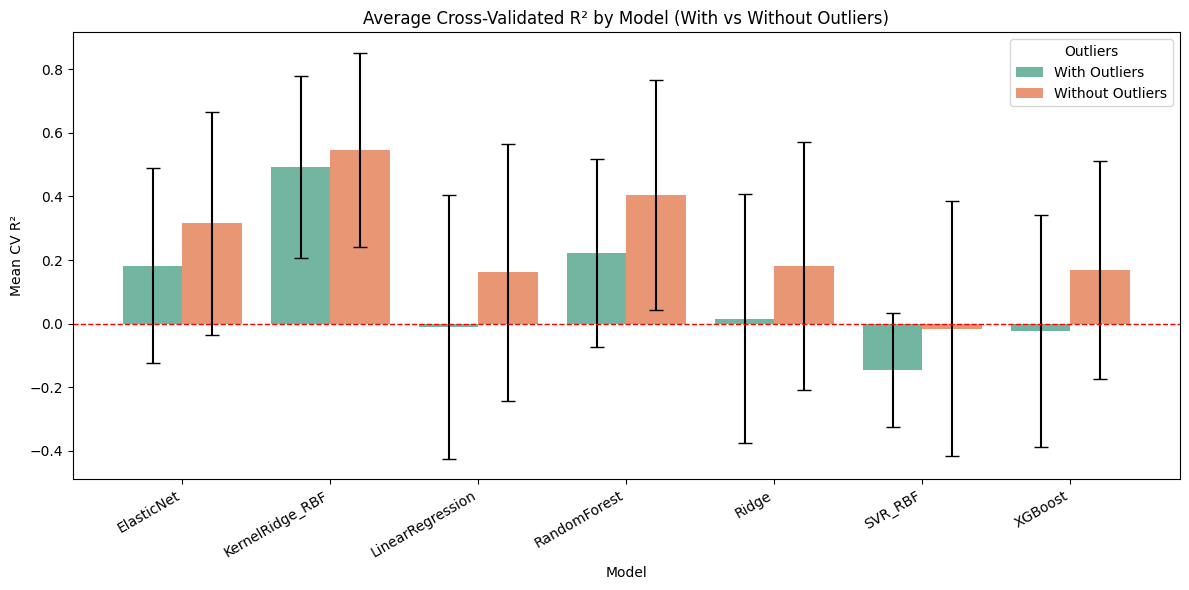

In [ ]:

files_with_outliers = {
    "LinearRegression": "linear_regression_metrics_all_traits.csv",
    "Ridge": "ridge_regression_metrics_all_traits.csv",
    "ElasticNet": "elasticnet_regression_metrics_all_traits.csv",
    "KernelRidge_RBF": "final_models_with_metrics_all_traits.csv",
    "SVR_RBF": "nonlinear_models_metrics_all_traits.csv",
    "RandomForest": "nonlinear_models_metrics_all_traits.csv",
    "XGBoost": "nonlinear_models_metrics_all_traits.csv"
}

files_no_outliers = {
    "LinearRegression": "linear_regression_metrics_all_traits_no_outliers.csv",
    "Ridge": "ridge_regression_metrics_all_traits_no_outliers.csv",
    "ElasticNet": "elasticnet_regression_metrics_all_traits_no_outliers.csv",
    "KernelRidge_RBF": "final_krr_metrics_no_outliers.csv",
    "SVR_RBF": "nonlinear_models_metrics_no_outliers.csv",
    "RandomForest": "nonlinear_models_metrics_no_outliers.csv",
    "XGBoost": "nonlinear_models_metrics_no_outliers.csv"
}

def load_results(file_map, with_outliers=True):
    all_results = []
    for model, path in file_map.items():
        df = pd.read_csv(path)

        # filter specific model if file contains multiple
        if "Model" in df.columns:
            df = df[df["Model"] == model.replace("_RBF", "")]

        df["Model"] = model
        df["Outliers"] = "With Outliers" if with_outliers else "Without Outliers"
        all_results.append(df)
    return pd.concat(all_results, ignore_index=True)

results_with = load_results(files_with_outliers, with_outliers=True)
results_no = load_results(files_no_outliers, with_outliers=False)

all_results = pd.concat([results_with, results_no], ignore_index=True)


#  Aggregate mean ± std

agg_results = (
    all_results.groupby(["Model", "Outliers"])["CV_Best_R2"]
    .agg(["mean", "std"])
    .reset_index()
)


#   summary tables

summary = agg_results.rename(columns={"mean": "Mean_CV_R2", "std": "Std_CV_R2"})
summary = summary.sort_values(["Outliers", "Mean_CV_R2"], ascending=[True, False])

print("\n=== Model Comparison (Mean ± Std of CV R²) ===")
display(summary)

# Separate tables for clarity
print("\n--- With Outliers ---")
display(summary[summary["Outliers"] == "With Outliers"])

print("\n--- Without Outliers ---")
display(summary[summary["Outliers"] == "Without Outliers"])

#  Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    data=agg_results,
    x="Model", y="mean", hue="Outliers",
    palette="Set2", capsize=0.2
)

# add error bars
for i, row in agg_results.iterrows():
    x = list(agg_results["Model"].unique()).index(row["Model"])
    offset = -0.2 if row["Outliers"] == "With Outliers" else 0.2
    plt.errorbar(
        x=x + offset,
        y=row["mean"],
        yerr=row["std"],
        fmt="none", c="black", capsize=5
    )

plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Average Cross-Validated R² by Model (With vs Without Outliers)")
plt.ylabel("Mean CV R²")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Outliers")
plt.tight_layout()
plt.show()


# Linear Models (OLS, Ridge, ElasticNet) + Gwas per trait for sensory

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ===========================
# Config
# ===========================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_regression(y_true, y_pred):
    return {
        "R2_in_sample": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

# ===========================
# Load GWAS results for sensory PCs
# ===========================
gwas_sensory = pd.read_csv("gwas_sensory_PCs.csv")

results_linear = []

for trait in gwas_sensory["Trait"].unique():
    print(f"\n[Linear Models] Trait: {trait}")
    gwas_df = gwas_sensory[gwas_sensory["Trait"] == trait]

    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        continue

    X = merged_snp_sensory[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        continue

    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = merged_snp_sensory[trait].astype(float).values

    models = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
    }

    for name, model in models.items():
        model.fit(X_scaled, y)
        y_pred = model.predict(X_scaled)

        metrics = evaluate_regression(y, y_pred)
        cv_r2 = np.mean(cross_val_score(model, X_scaled, y, cv=3, scoring="r2"))

        results_linear.append({
            "Trait": trait,
            "Model": name,
            "n_SNPs": X_pruned.shape[1],
            "CV_Best_R2": cv_r2,
            **metrics
        })

# Save results
results_df_linear = pd.DataFrame(results_linear)
results_df_linear.to_csv("linear_models_sensory_PCs.csv", index=False)
print("\ Linear models results saved to linear_models_sensory_PCs.csv")
display(results_df_linear.sort_values("CV_Best_R2", ascending=False).head(10))


<>:67: SyntaxWarning: invalid escape sequence '\ '
<>:67: SyntaxWarning: invalid escape sequence '\ '
C:\Users\fatemehm\AppData\Local\Temp\ipykernel_9256\2948951057.py:67: SyntaxWarning: invalid escape sequence '\ '
  print("\ Linear models results saved to linear_models_sensory_PCs.csv")



[Linear Models] Trait: PC1

[Linear Models] Trait: PC2

[Linear Models] Trait: PC3
\ Linear models results saved to linear_models_sensory_PCs.csv


,Trait,Model,n_SNPs,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
7,PC3,Ridge,272,0.484220,0.999920,4.066790e-05,6.377139e-03,4.917084e-03
6,PC3,LinearRegression,272,0.478901,1.000000,1.951242e-30,1.396869e-15,1.092167e-15
5,PC2,ElasticNet,88,0.424647,0.792737,2.334270e-01,4.831428e-01,3.899851e-01
2,PC1,ElasticNet,138,0.397104,0.803094,3.492720e-01,5.909924e-01,4.755973e-01
8,PC3,ElasticNet,272,0.386887,0.887025,5.778608e-02,2.403874e-01,1.958082e-01
1,PC1,Ridge,138,-0.001684,0.988189,2.094961e-02,1.447398e-01,1.010138e-01
0,PC1,LinearRegression,138,-0.226421,1.000000,8.977915e-30,2.996317e-15,2.372057e-15
4,PC2,Ridge,88,-0.243069,0.953318,5.257502e-02,2.292924e-01,1.718492e-01
3,PC2,LinearRegression,88,-1.216239,0.985630,1.618457e-02,1.272186e-01,9.598651e-02


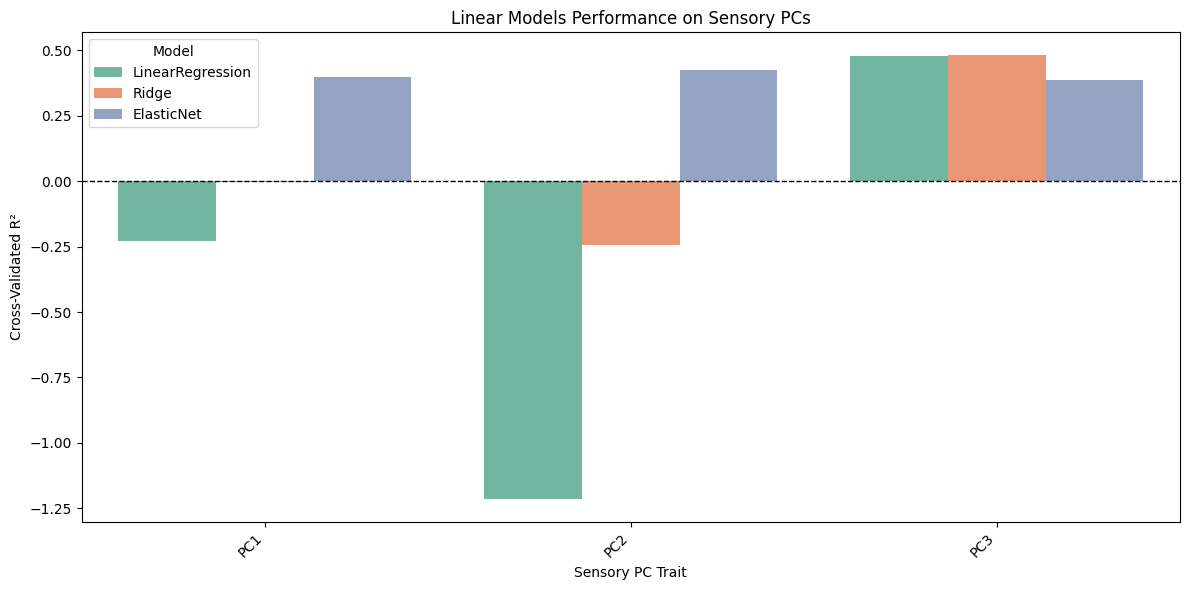

In [ ]:

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_linear,
    x="Trait",
    y="CV_Best_R2",
    hue="Model",
    palette="Set2"
)

plt.xticks(rotation=45, ha="right")
plt.title("Linear Models Performance on Sensory PCs")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Sensory PC Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


# Kernel Ridge Regression + Gwas per trait for sensory

In [ ]:


param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1]
}

results_krr = []

for trait in gwas_sensory["Trait"].unique():
    print(f"\n[KRR] Trait: {trait}")
    gwas_df = gwas_sensory[gwas_sensory["Trait"] == trait]

    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        continue

    X = merged_snp_sensory[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        continue

    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = merged_snp_sensory[trait].astype(float).values

    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid=param_grid,
        cv=3,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_scaled, y)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_scaled)

    metrics = evaluate_regression(y, y_pred)

    results_krr.append({
        "Trait": trait,
        "Model": "KernelRidge",
        "n_SNPs": X_pruned.shape[1],
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_Best_R2": grid.best_score_,
        **metrics
    })

# Save results
results_df_krr = pd.DataFrame(results_krr)
results_df_krr.to_csv("krr_models_sensory_PCs.csv", index=False)
print("\n KRR results saved to krr_models_sensory_PCs.csv")
display(results_df_krr.sort_values("CV_Best_R2", ascending=False).head(10))



[KRR] Trait: PC1

[KRR] Trait: PC2

[KRR] Trait: PC3

 KRR results saved to krr_models_sensory_PCs.csv


,Trait,Model,n_SNPs,Best_alpha,Best_gamma,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
2,PC3,KernelRidge,272,0.10,0.0001,0.604892,0.805612,0.099429,0.315323,0.253811
0,PC1,KernelRidge,138,0.01,0.0001,0.530938,0.845791,0.273536,0.523007,0.409203
1,PC2,KernelRidge,88,0.01,0.0001,0.513718,0.816615,0.206535,0.454461,0.363930


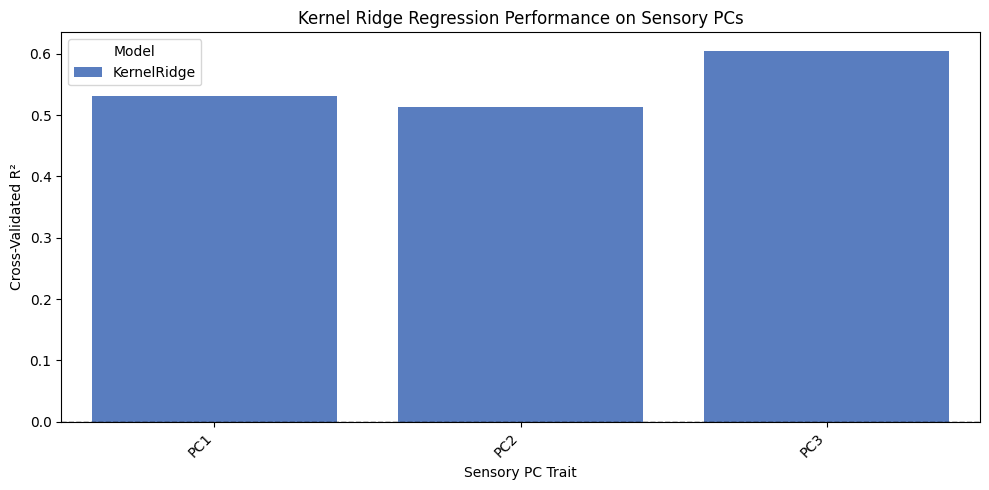

In [ ]:

# Visualization for KRR
plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df_krr,
    x="Trait",
    y="CV_Best_R2",
    hue="Model",   # though here it's only "KernelRidge"
    palette="muted"
)

plt.xticks(rotation=45, ha="right")
plt.title("Kernel Ridge Regression Performance on Sensory PCs")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Sensory PC Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


# Nonlinear Models (SVR, RandomForest, XGBoost) + Gwas per treit for seensory

In [ ]:


results_nonlinear = []

nonlinear_models = {
    "SVR": SVR(kernel="rbf", C=10, gamma=0.1),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.1,
        max_depth=4, random_state=42, n_jobs=-1
    )
}

for trait in gwas_sensory["Trait"].unique():
    print(f"\n[Nonlinear Models] Trait: {trait}")
    gwas_df = gwas_sensory[gwas_sensory["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        continue

    X = merged_snp_sensory[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)

    if X_pruned.shape[1] == 0:
        continue

    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = merged_snp_sensory[trait].astype(float).values

    # loop over nonlinear models
    for name, model in nonlinear_models.items():
        model.fit(X_scaled, y)
        y_pred = model.predict(X_scaled)

        metrics = evaluate_regression(y, y_pred)
        cv_r2 = np.mean(cross_val_score(model, X_scaled, y, cv=cv, scoring="r2"))

        results_nonlinear.append({
            "Trait": trait,
            "Model": name,
            "n_SNPs": X_pruned.shape[1],
            "CV_Best_R2": cv_r2,
            **metrics
        })

# Save results
results_df_nonlinear = pd.DataFrame(results_nonlinear)
results_df_nonlinear.to_csv("nonlinear_models_sensory_PCs.csv", index=False)

print("\ Nonlinear models results saved to nonlinear_models_sensory_PCs.csv")
display(results_df_nonlinear.sort_values("CV_Best_R2", ascending=False).head(10))


<>:50: SyntaxWarning: invalid escape sequence '\ '
<>:50: SyntaxWarning: invalid escape sequence '\ '
C:\Users\fatemehm\AppData\Local\Temp\ipykernel_9256\1243009963.py:50: SyntaxWarning: invalid escape sequence '\ '
  print("\ Nonlinear models results saved to nonlinear_models_sensory_PCs.csv")



[Nonlinear Models] Trait: PC1

[Nonlinear Models] Trait: PC2

[Nonlinear Models] Trait: PC3
\ Nonlinear models results saved to nonlinear_models_sensory_PCs.csv


,Trait,Model,n_SNPs,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
1,PC1,RandomForest,138,0.378078,0.913451,1.535205e-01,0.391817,0.304064
4,PC2,RandomForest,88,0.280192,0.907159,1.045615e-01,0.323360,0.255860
2,PC1,XGBoost,138,0.258485,0.999999,1.619102e-06,0.001272,0.000850
5,PC2,XGBoost,88,0.224759,0.999999,1.189545e-06,0.001091,0.000725
7,PC3,RandomForest,272,0.069924,0.915819,4.305841e-02,0.207505,0.162175
8,PC3,XGBoost,272,-0.007544,0.999999,3.701669e-07,0.000608,0.000450
3,PC2,SVR,88,-0.015106,0.991533,9.536348e-03,0.097654,0.097080
0,PC1,SVR,138,-0.050284,0.994431,9.877713e-03,0.099387,0.099121
6,PC3,SVR,272,-0.564807,0.982762,8.817018e-03,0.093899,0.089085


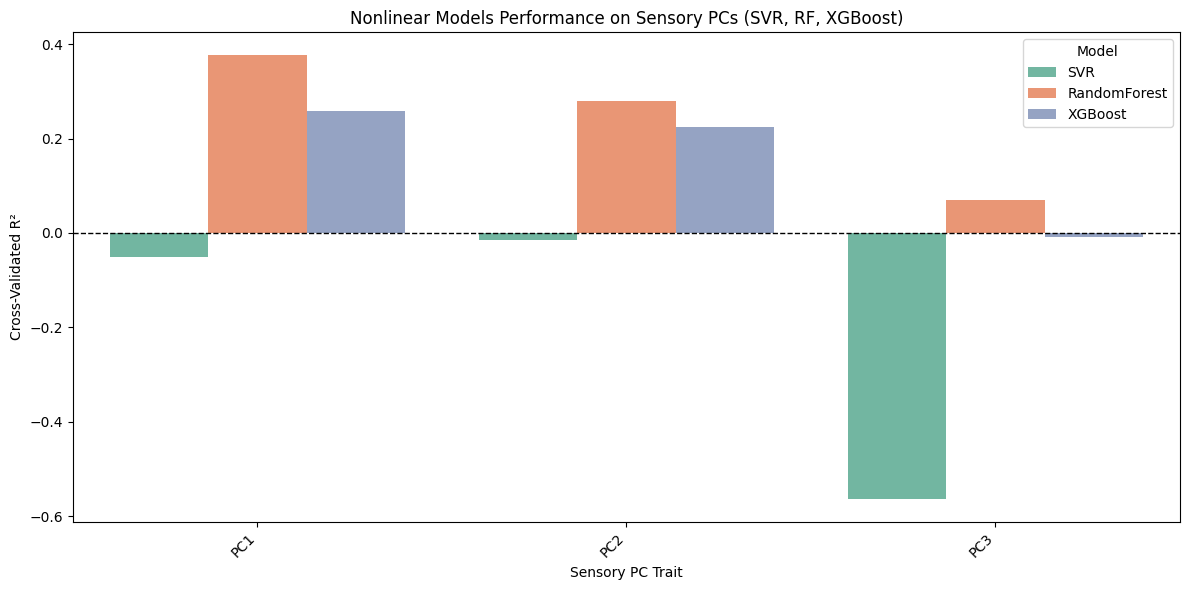

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_nonlinear,
    x="Trait",
    y="CV_Best_R2",
    hue="Model",
    palette="Set2"
)

plt.xticks(rotation=45, ha="right")
plt.title("Nonlinear Models Performance on Sensory PCs (SVR, RF, XGBoost)")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Sensory PC Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# removing outliers

In [ ]:
# Remove outliers
outliers = {"ARGOS", "NADINE"}
df_sensory_no_outliers = merged_snp_sensory.drop(index=[o for o in outliers if o in merged_snp_sensory.index])


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet

results_linear = []

for trait in gwas_sensory["Trait"].unique():
    print(f"\n[Linear Models] Trait: {trait}")
    gwas_df = gwas_sensory[gwas_sensory["Trait"] == trait]

    # pick top SNPs
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        continue

    X = df_sensory_no_outliers[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)
    if X_pruned.shape[1] == 0:
        continue

    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = df_sensory_no_outliers[trait].astype(float).values

    models = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
    }

    for name, model in models.items():
        model.fit(X_scaled, y)
        y_pred = model.predict(X_scaled)
        metrics = evaluate_regression(y, y_pred)
        cv_r2 = np.mean(cross_val_score(model, X_scaled, y, cv=cv, scoring="r2"))

        results_linear.append({
            "Trait": trait,
            "Model": name,
            "n_SNPs": X_pruned.shape[1],
            "CV_Best_R2": cv_r2,
            **metrics
        })

results_df_linear_no_outliers = pd.DataFrame(results_linear)
results_df_linear_no_outliers.to_csv("linear_models_sensory_PCs_no_outliers.csv", index=False)


print("\n Linear models results saved to linear_models_sensory_PCs_no_outliers.csv")
display(results_df_linear_no_outliers.sort_values("CV_Best_R2", ascending=False).head(10))



[Linear Models] Trait: PC1

[Linear Models] Trait: PC2

[Linear Models] Trait: PC3

 Linear models results saved to linear_models_sensory_PCs_no_outliers.csv


,Trait,Model,n_SNPs,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
7,PC3,Ridge,268,0.485422,0.999919,4.236567e-05,6.508891e-03,5.056112e-03
6,PC3,LinearRegression,268,0.480005,1.000000,3.675324e-30,1.917113e-15,1.535859e-15
2,PC1,ElasticNet,138,0.444472,0.804806,3.533018e-01,5.943919e-01,4.825071e-01
5,PC2,ElasticNet,88,0.375198,0.797661,2.298161e-01,4.793914e-01,3.855160e-01
8,PC3,ElasticNet,268,0.305277,0.888374,5.814102e-02,2.411245e-01,1.974065e-01
1,PC1,Ridge,138,-0.380142,0.991143,1.603126e-02,1.266146e-01,9.135512e-02
4,PC2,Ridge,88,-0.445634,0.962298,4.282201e-02,2.069348e-01,1.535243e-01
0,PC1,LinearRegression,138,-0.737217,1.000000,1.018876e-29,3.191984e-15,2.527435e-15
3,PC2,LinearRegression,88,-3.171396,0.994650,6.076478e-03,7.795177e-02,5.682456e-02


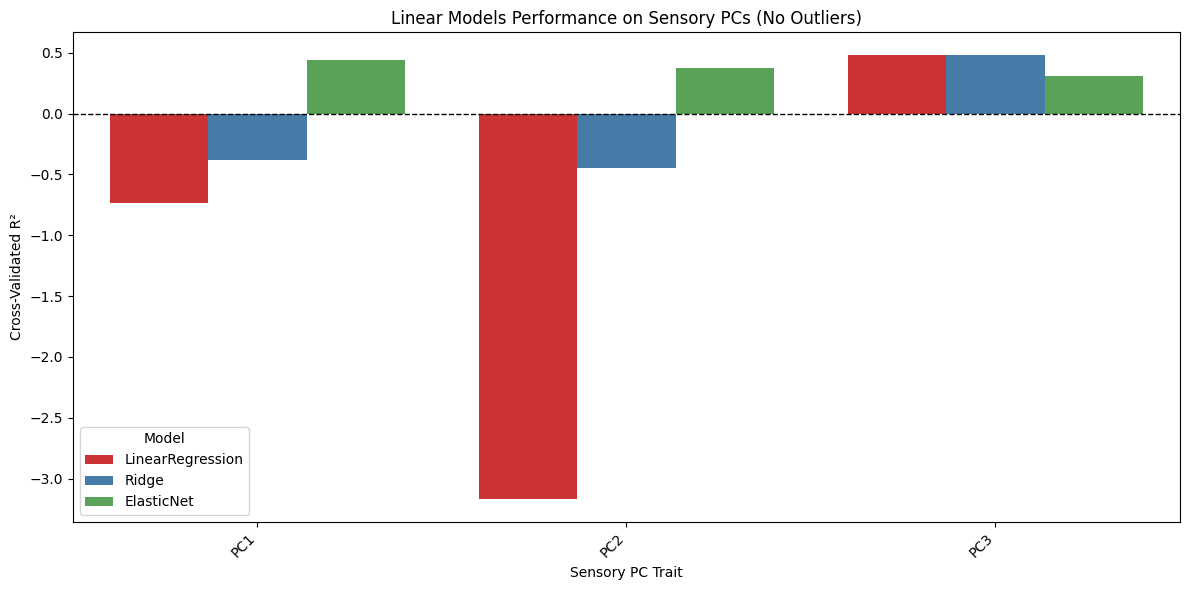

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_linear_no_outliers,
    x="Trait",
    y="CV_Best_R2",
    hue="Model",
    palette="Set1"
)

plt.xticks(rotation=45, ha="right")
plt.title("Linear Models Performance on Sensory PCs (No Outliers)")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Sensory PC Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [ ]:
param_grid = {
    "alpha": [0.01, 0.1, 1, 10],
    "gamma": [1e-3, 1e-2, 0.1, 1]
}

results_krr = []

for trait in gwas_sensory["Trait"].unique():
    print(f"\n[KRR] Trait: {trait}")
    gwas_df = gwas_sensory[gwas_sensory["Trait"] == trait]
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        continue

    X = df_sensory_no_outliers[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)
    if X_pruned.shape[1] == 0:
        continue

    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = df_sensory_no_outliers[trait].astype(float).values

    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_scaled, y)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_scaled)
    metrics = evaluate_regression(y, y_pred)

    results_krr.append({
        "Trait": trait,
        "Model": "KRR",
        "n_SNPs": X_pruned.shape[1],
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_Best_R2": grid.best_score_,
        **metrics
    })

results_df_krr_no_outliers = pd.DataFrame(results_krr)
results_df_krr_no_outliers.to_csv("krr_models_sensory_PCs_no_outliers.csv", index=False)
display(results_df_krr_no_outliers.sort_values("CV_Best_R2", ascending=False).head(10))



[KRR] Trait: PC1

[KRR] Trait: PC2

[KRR] Trait: PC3


,Trait,Model,n_SNPs,Best_alpha,Best_gamma,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
2,PC3,KRR,268,0.1,0.001,0.558460,0.966336,0.017534,0.132416,0.104220
0,PC1,KRR,138,0.1,0.001,0.512356,0.859356,0.254565,0.504544,0.396594
1,PC2,KRR,88,0.1,0.001,0.486722,0.836707,0.185468,0.430659,0.341111


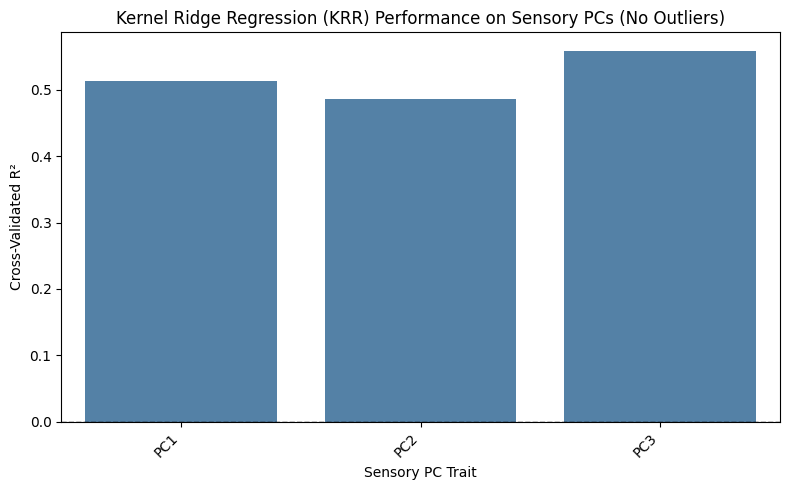

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_df_krr_no_outliers,
    x="Trait",
    y="CV_Best_R2",
    color="steelblue"
)

plt.xticks(rotation=45, ha="right")
plt.title("Kernel Ridge Regression (KRR) Performance on Sensory PCs (No Outliers)")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Sensory PC Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
results_nonlinear = []

nonlinear_models = {
    "SVR": SVR(kernel="rbf", C=10, gamma=0.1),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.1,
        max_depth=4, random_state=42, n_jobs=-1
    )
}

for trait in gwas_sensory["Trait"].unique():
    print(f"\n[Nonlinear Models] Trait: {trait}")
    gwas_df = gwas_sensory[gwas_sensory["Trait"] == trait]
    top_snps = gwas_df.sort_values("p_fdr").head(1500)["SNP"].tolist()
    if not top_snps:
        continue

    X = df_sensory_no_outliers[top_snps].fillna(0).astype(float)
    X_pruned = ld_prune(X, threshold=0.95)
    if X_pruned.shape[1] == 0:
        continue

    X_scaled = StandardScaler().fit_transform(X_pruned)
    y = df_sensory_no_outliers[trait].astype(float).values

    for name, model in nonlinear_models.items():
        model.fit(X_scaled, y)
        y_pred = model.predict(X_scaled)
        metrics = evaluate_regression(y, y_pred)
        cv_r2 = np.mean(cross_val_score(model, X_scaled, y, cv=cv, scoring="r2"))

        results_nonlinear.append({
            "Trait": trait,
            "Model": name,
            "n_SNPs": X_pruned.shape[1],
            "CV_Best_R2": cv_r2,
            **metrics
        })

results_df_nonlinear_no_outliers = pd.DataFrame(results_nonlinear)
results_df_nonlinear_no_outliers.to_csv("nonlinear_models_sensory_PCs_no_outliers.csv", index=False)

print("\n Linear models results saved to linear_models_sensory_PCs_no_outliers.csv")
display(results_df_nonlinear_no_outliers.sort_values("CV_Best_R2", ascending=False).head(10))


[Nonlinear Models] Trait: PC1

[Nonlinear Models] Trait: PC2

[Nonlinear Models] Trait: PC3

 Linear models results saved to linear_models_sensory_PCs_no_outliers.csv


,Trait,Model,n_SNPs,CV_Best_R2,R2_in_sample,MSE,RMSE,MAE
1,PC1,RandomForest,138,0.417310,0.913532,1.565077e-01,0.395610,0.313478
7,PC3,RandomForest,268,0.332577,0.913299,4.515844e-02,0.212505,0.170440
4,PC2,RandomForest,88,0.295031,0.903071,1.100917e-01,0.331801,0.253200
2,PC1,XGBoost,138,0.280058,0.999999,2.644289e-06,0.001626,0.001080
8,PC3,XGBoost,268,0.269596,0.999999,4.118195e-07,0.000642,0.000468
5,PC2,XGBoost,88,0.150746,0.999999,1.489308e-06,0.001220,0.000793
0,PC1,SVR,138,-0.012458,0.994545,9.873879e-03,0.099367,0.099107
6,PC3,SVR,268,-0.049900,0.983100,8.802435e-03,0.093821,0.089414
3,PC2,SVR,88,-0.053300,0.991624,9.512884e-03,0.097534,0.096928


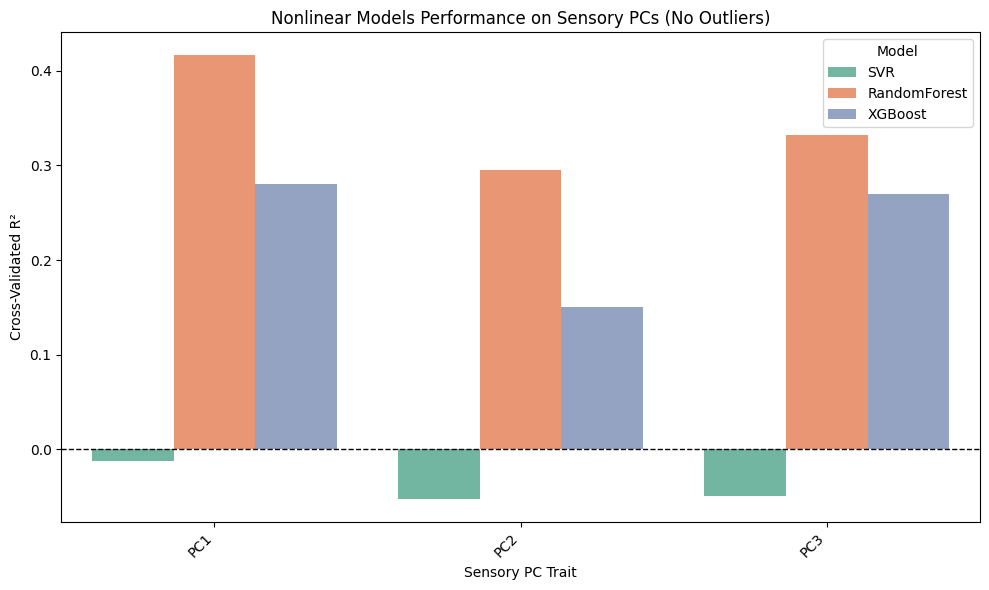

In [ ]:

# Visualization for Nonlinear Models (No Outliers)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df_nonlinear_no_outliers,
    x="Trait",
    y="CV_Best_R2",
    hue="Model",
    palette="Set2"
)

plt.xticks(rotation=45, ha="right")
plt.title("Nonlinear Models Performance on Sensory PCs (No Outliers)")
plt.ylabel("Cross-Validated R²")
plt.xlabel("Sensory PC Trait")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


# Top gene for  each traits.

In [ ]:

# Dictionary to hold trait → top SNPs
top_snps_per_trait = {}

for trait in gwas_sensory["Trait"].unique():
    df_trait = gwas_sensory[gwas_sensory["Trait"] == trait]
    
    # Select SNPs with lowest FDR (e.g., top 50 markers)
    top_snps = df_trait.sort_values("p_fdr").head(50)["SNP"].tolist()
    
    top_snps_per_trait[trait] = top_snps
    print(f"\nTrait: {trait} → {len(top_snps)} SNPs")
    print(top_snps[:10])  # print first 10 for preview

# Save to CSV (optional)
all_snps_df = pd.DataFrame([
    {"Trait": trait, "SNP": snp}
    for trait, snps in top_snps_per_trait.items()
    for snp in snps
])
all_snps_df.to_csv("top_snps_per_trait.csv", index=False)

print("\n Top SNPs per trait saved to top_snps_per_trait.csv")



Trait: PC1 → 50 SNPs
['GEN__127494', 'GEN__402621', 'GEN__18557', 'GEN__8423', 'GEN__119383', 'GEN__8413', 'GEN__119266', 'GEN__119305', 'GEN__119748', 'GEN__119710']

Trait: PC2 → 50 SNPs
['GEN__311689', 'GEN__490013', 'GEN__227309', 'GEN__227350', 'GEN__25684', 'GEN__31805', 'GEN__312136', 'GEN__489883', 'GEN__312045', 'GEN__311992']

Trait: PC3 → 50 SNPs
['GEN__59842', 'GEN__6314', 'GEN__7650', 'GEN__7617', 'GEN__7700', 'GEN__7739', 'GEN__6015', 'GEN__353948', 'GEN__1950', 'GEN__559360']

 Top SNPs per trait saved to top_snps_per_trait.csv



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\upsetplot\data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate objec

<Figure size 1000x600 with 0 Axes>

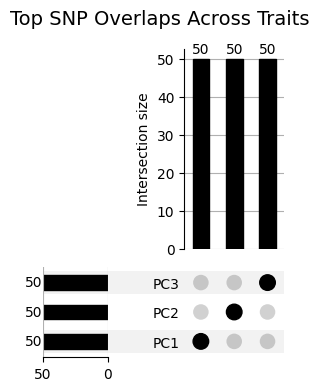

In [ ]:
!pip install upsetplot



from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

# Build memberships: SNP → traits (as tuple)
memberships = [
    tuple(sorted(traits))   # sort to avoid (A,B) vs (B,A) being different
    for snp, traits in all_snps_df.groupby("SNP")["Trait"]
]

# Count occurrences of each unique membership
from collections import Counter
counts = Counter(memberships)

# Convert to UpSet input
data_upset = from_memberships(list(counts.keys()), data=list(counts.values()))

# Plot
plt.figure(figsize=(10,6))
UpSet(data_upset, show_counts=True, show_percentages=False).plot()
plt.suptitle("Top SNP Overlaps Across Traits", fontsize=14)
plt.show()


In [ ]:
# Load GWAS results for aroma traits
gwas_aroma = pd.read_csv("gwas_aroma_all_traits.csv")  # adjust path if needed

# Dictionary to hold trait → top SNPs
top_snps_per_trait_aroma = {}

for trait in gwas_aroma["Trait"].unique():
    df_trait = gwas_aroma[gwas_aroma["Trait"] == trait]
    
    # Select SNPs with lowest FDR (e.g., top 50 markers)
    top_snps = df_trait.sort_values("p_fdr").head(50)["SNP"].tolist()
    
    top_snps_per_trait_aroma[trait] = top_snps
    print(f"\nTrait: {trait} → {len(top_snps)} SNPs")
    print(top_snps[:10])  # preview first 10

# Save to CSV (optional)
all_snps_df_aroma = pd.DataFrame([
    {"Trait": trait, "SNP": snp}
    for trait, snps in top_snps_per_trait_aroma.items()
    for snp in snps
])
all_snps_df_aroma.to_csv("top_snps_per_trait_aroma.csv", index=False)

print("\n Top SNPs per aroma trait saved to top_snps_per_trait_aroma.csv")



Trait: 1-Nonanol (Floral, waxy) → 50 SNPs
['GEN__39329', 'GEN__39613', 'GEN__39565', 'GEN__40967', 'GEN__40914', 'GEN__40854', 'GEN__40813', 'GEN__40735', 'GEN__40678', 'GEN__40639']

Trait: 1-Octen-3-ol (Mushroom, earthy) → 50 SNPs
['GEN__431521', 'GEN__239389', 'GEN__254255', 'GEN__242043', 'GEN__195743', 'GEN__211365', 'GEN__211276', 'GEN__5805', 'GEN__211177', 'GEN__212082']

Trait: 2,3-Butanedione (Butter, creamy, sweet) → 50 SNPs
['GEN__431521', 'GEN__239389', 'GEN__254255', 'GEN__242043', 'GEN__195743', 'GEN__211365', 'GEN__211276', 'GEN__5805', 'GEN__211177', 'GEN__212082']

Trait: Acetic acid (Vinegar, sour) → 50 SNPs
['GEN__168934', 'GEN__44705', 'GEN__44742', 'GEN__44635', 'GEN__44588', 'GEN__44589', 'GEN__44549', 'GEN__563972', 'GEN__45565', 'GEN__45506']

Trait: Benzaldehyde (Almond, cherry, fruity) → 50 SNPs
['GEN__7', 'GEN__564828', 'GEN__564807', 'GEN__564804', 'GEN__564802', 'GEN__564800', 'GEN__125', 'GEN__124', 'GEN__177', 'GEN__176']

Trait: Butanal, 3-methyl- (Fru

c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\upsetplot\data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original

<Figure size 1000x600 with 0 Axes>

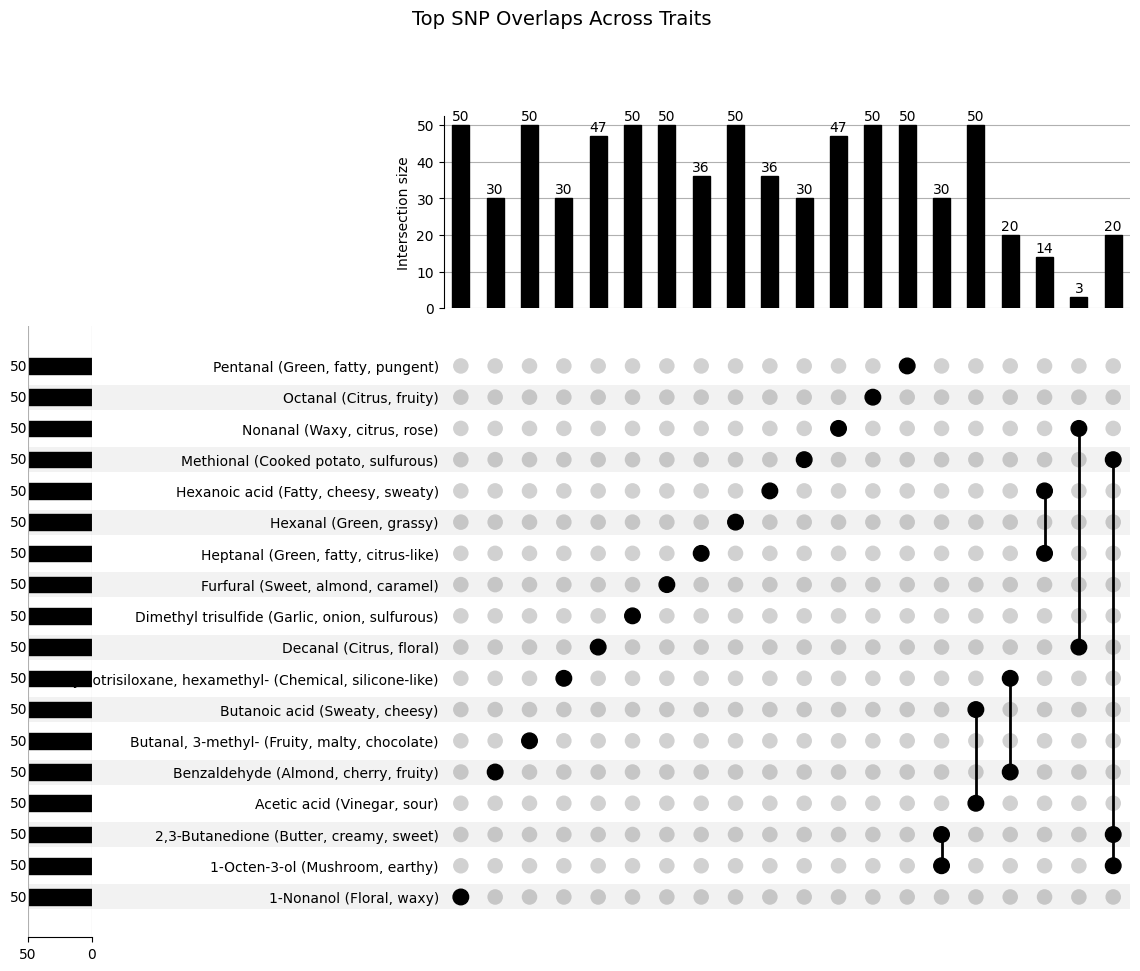

In [ ]:
# Build memberships: SNP → traits (as tuple)
memberships = [
    tuple(sorted(traits))   # sort to avoid (A,B) vs (B,A) being different
    for snp, traits in all_snps_df_aroma.groupby("SNP")["Trait"]
]

# Count occurrences of each unique membership
from collections import Counter
counts = Counter(memberships)

# Convert to UpSet input
data_upset = from_memberships(list(counts.keys()), data=list(counts.values()))

# Plot
plt.figure(figsize=(10,6))
UpSet(data_upset, show_counts=True, show_percentages=False).plot()
plt.suptitle("Top SNP Overlaps Across Traits", fontsize=14)
plt.show()


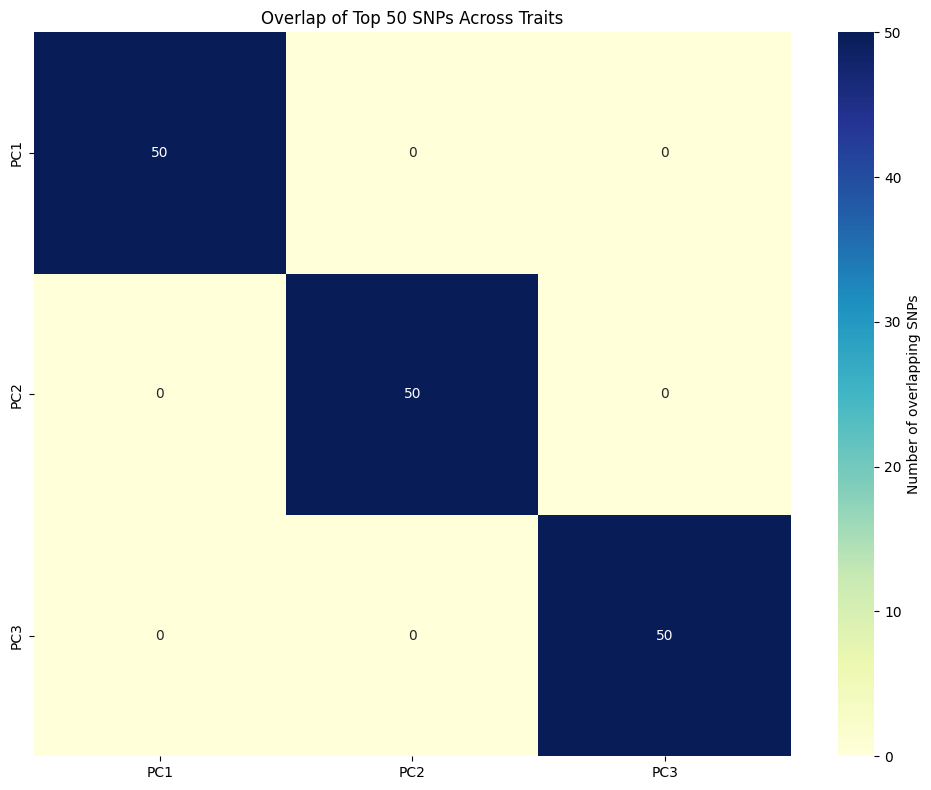

In [ ]:


# Build dictionary of SNP sets
trait_to_snps = {
    trait: set(df_trait.sort_values("p_fdr").head(50)["SNP"])
    for trait, df_trait in gwas_sensory.groupby("Trait")
}

# Build overlap matrix
traits = list(trait_to_snps.keys())
overlap_matrix = pd.DataFrame(0, index=traits, columns=traits)

for t1 in traits:
    for t2 in traits:
        overlap_matrix.loc[t1, t2] = len(trait_to_snps[t1] & trait_to_snps[t2])

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(overlap_matrix, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Number of overlapping SNPs"})
plt.title("Overlap of Top 50 SNPs Across Traits")
plt.tight_layout()
plt.show()


# SNP Overlap Among Aroma Traits (Top 50 SNPs)

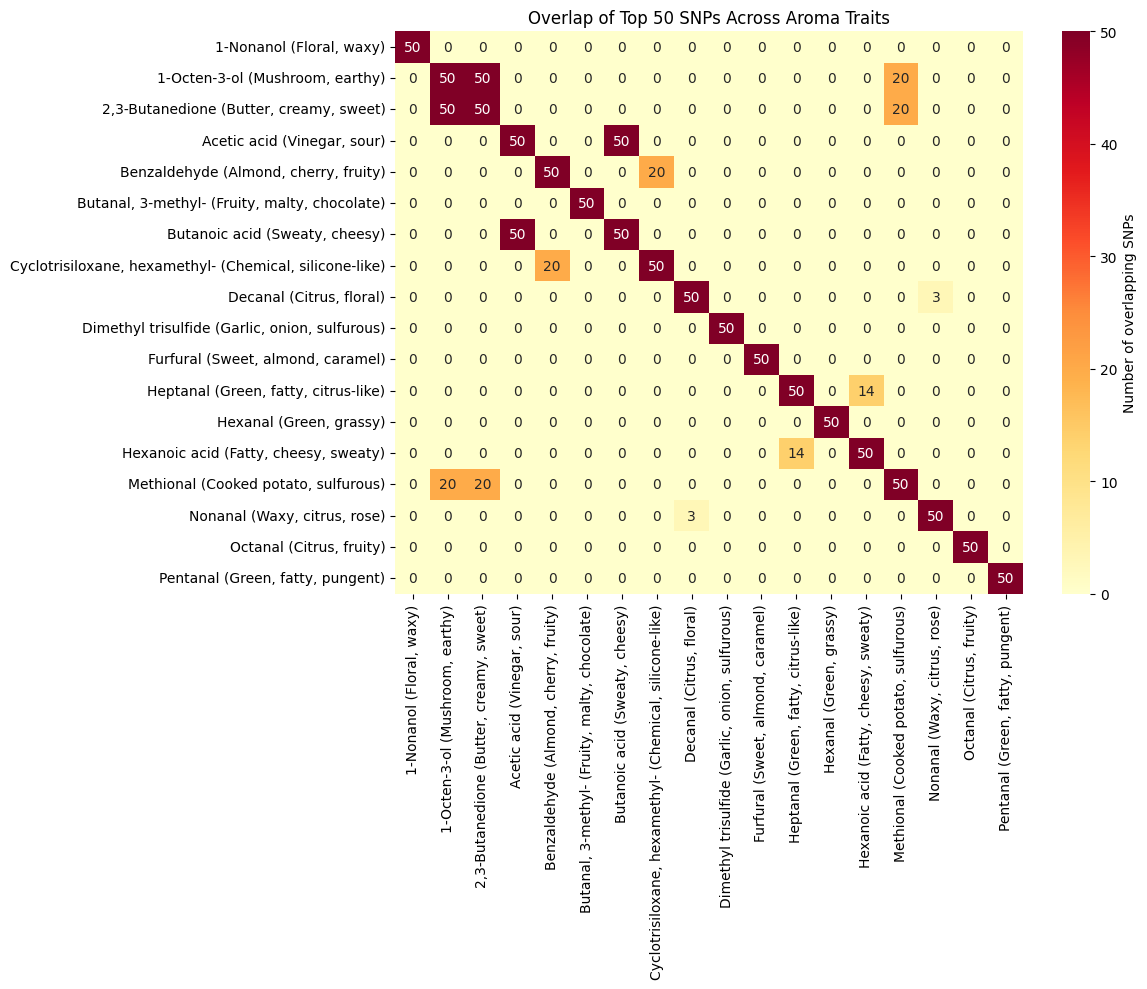

In [ ]:

# SNP Overlap Heatmap for Aroma traits
# Build dictionary of SNP sets per aroma trait
trait_to_snps_aroma = {
    trait: set(df_trait.sort_values("p_fdr").head(50)["SNP"])
    for trait, df_trait in gwas_aroma.groupby("Trait")
}

# Build overlap matrix
traits_aroma = list(trait_to_snps_aroma.keys())
overlap_matrix_aroma = pd.DataFrame(0, index=traits_aroma, columns=traits_aroma)

for t1 in traits_aroma:
    for t2 in traits_aroma:
        overlap_matrix_aroma.loc[t1, t2] = len(trait_to_snps_aroma[t1] & trait_to_snps_aroma[t2])

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    overlap_matrix_aroma, 
    annot=True, fmt="d", cmap="YlOrRd", 
    cbar_kws={"label": "Number of overlapping SNPs"}
)
plt.title("Overlap of Top 50 SNPs Across Aroma Traits")
plt.tight_layout()
plt.show()


# GWAS_Aroma_Sensory_Correlations

In [ ]:

# 3) Aroma–Sensory correlations
rows = []

# use numeric columns only
aroma_traits = gwas_aroma["Trait"].unique()
sensory_traits = gwas_sensory["Trait"].unique()

for aroma in aroma_traits:
    for pc in sensory_traits:
        if aroma in merged_all.columns and pc in merged_all.columns:
            corr = merged_all[aroma].corr(merged_all[pc])
            rows.append({"Aroma": aroma, "PC": pc, "Correlation": corr})

# Build DataFrame
aroma_sensory_corr = pd.DataFrame(rows)

# Save results
aroma_sensory_corr.to_csv("Aroma_Sensory_Correlations.csv", index=False)

print("\n=== Aroma–Sensory correlations ===")
print(aroma_sensory_corr.head(10))
print("\nSaved correlations to Aroma_Sensory_Correlations.csv")



=== Aroma–Sensory correlations ===
                                     Aroma   PC  Correlation
0                 1-Nonanol (Floral, waxy)  PC1     0.044046
1                 1-Nonanol (Floral, waxy)  PC2    -0.202291
2                 1-Nonanol (Floral, waxy)  PC3     0.029258
3          1-Octen-3-ol (Mushroom, earthy)  PC1     0.110053
4          1-Octen-3-ol (Mushroom, earthy)  PC2    -0.052245
5          1-Octen-3-ol (Mushroom, earthy)  PC3    -0.103142
6  2,3-Butanedione (Butter, creamy, sweet)  PC1     0.110053
7  2,3-Butanedione (Butter, creamy, sweet)  PC2    -0.052245
8  2,3-Butanedione (Butter, creamy, sweet)  PC3    -0.103142
9              Acetic acid (Vinegar, sour)  PC1    -0.062500

Saved correlations to Aroma_Sensory_Correlations.csv


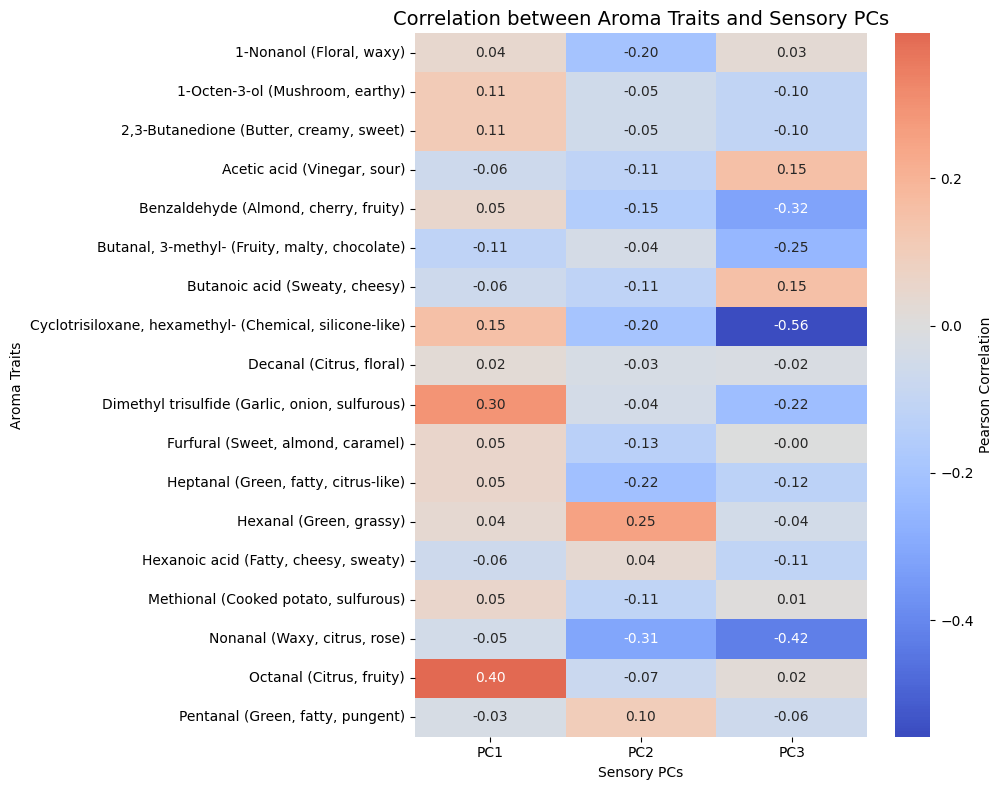

In [ ]:


# Pivot correlation DataFrame into matrix form
heatmap_data = aroma_sensory_corr.pivot(
    index="Aroma", columns="PC", values="Correlation"
)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title("Correlation between Aroma Traits and Sensory PCs", fontsize=14)
plt.ylabel("Aroma Traits")
plt.xlabel("Sensory PCs")
plt.tight_layout()
plt.show()


# Prediction of sensory by aroma

In [ ]:

# -----------------------
# Data
# -----------------------
# Assuming merged_all is already loaded
aroma_cols = [c for c in merged_all.columns if "(" in c and "GEN__" not in c and "PC" not in c]
sensory_cols = ["PC1", "PC2", "PC3"]

X = merged_all[aroma_cols].astype(float)
Y = merged_all[sensory_cols].astype(float)

# Drop rows where either X or Y has NaNs
merged = pd.concat([X, Y], axis=1).dropna()
X = merged[aroma_cols]
Y = merged[sensory_cols]

print("Missing values after cleanup:")
print(Y.isna().sum())  # should all be 0 now

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------
# PCA / PLS toggle (set to True to use)
# -----------------------
USE_PCA = False
USE_PLS = False
N_COMPONENTS = 10  # adjust based on variance explained

if USE_PCA:
    pca = PCA(n_components=N_COMPONENTS, random_state=42)
    X = pca.fit_transform(X)

if USE_PLS:
    pls = PLSRegression(n_components=min(N_COMPONENTS, X.shape[1]))
    X, _ = pls.fit_transform(X, Y)

# -----------------------
# Models and grids
# -----------------------
models = {
    "LinearRegression": (
        Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
        {}
    ),
    "Ridge": (
        Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
        {"model__alpha": [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1000]}
    ),
    "KernelRidge": (
        Pipeline([("scaler", StandardScaler()), ("model", KernelRidge())]),
        {"model__alpha": [1e-3, 1e-2, 0.1, 1, 10],
         "model__gamma": [1e-4, 1e-3, 1e-2, 0.1, 1],
         "model__kernel": ["rbf", "poly", "sigmoid"]}
    ),
    "SVR": (
        Pipeline([("scaler", StandardScaler()), ("model", SVR())]),
        {"model__C": [0.01, 0.1, 1, 10, 100],
         "model__gamma": ["scale", "auto", 1e-3, 1e-2, 0.1],
         "model__epsilon": [0.01, 0.1, 0.5, 1.0],
         "model__kernel": ["rbf", "poly"]}
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {"n_estimators": [200, 500, 800],
         "max_depth": [None, 5, 10, 20],
         "max_features": ["sqrt", "log2", None],
         "min_samples_split": [2, 5, 10],
         "min_samples_leaf": [1, 2, 4]}
    ),
    "XGBoost": (
        XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
        {"n_estimators": [300, 500, 800],
         "learning_rate": [0.01, 0.05, 0.1, 0.3],
         "max_depth": [3, 5, 7, 9],
         "subsample": [0.6, 0.8, 1.0],
         "colsample_bytree": [0.6, 0.8, 1.0],
         "reg_alpha": [0, 0.1, 1],
         "reg_lambda": [1, 5, 10]}
    )
}


# Training loop
results = []

for pc in sensory_cols:
    y = Y[pc].values

    for model_name, (estimator, param_grid) in models.items():
        print(f"\n=== {model_name} for {pc} ===")
        grid = GridSearchCV(
            estimator,
            param_grid,
            cv=cv,
            scoring="r2",
            n_jobs=-1,
            error_score="raise"  # so we see the real error if it happens
        )
        grid.fit(X, y)

        results.append({
            "PC": pc,
            "Model": model_name,
            "Best_params": grid.best_params_,
            "CV_R2_mean": grid.best_score_
        })

results_df = pd.DataFrame(results)
print("\n=== Final Comparison (GCMS → Sensory PCs) ===")
print(results_df.sort_values(["PC", "CV_R2_mean"], ascending=[True, False]))

# Save results
results_df.to_csv("gcms_to_sensory_model_comparison.csv", index=False)


Missing values after cleanup:
PC1    0
PC2    0
PC3    0
dtype: int64

=== LinearRegression for PC1 ===

=== Ridge for PC1 ===

=== KernelRidge for PC1 ===

=== SVR for PC1 ===

=== RandomForest for PC1 ===

=== XGBoost for PC1 ===

=== LinearRegression for PC2 ===

=== Ridge for PC2 ===

=== KernelRidge for PC2 ===

=== SVR for PC2 ===

=== RandomForest for PC2 ===

=== XGBoost for PC2 ===


KeyboardInterrupt: 

Shared GEN markers: 262434

Top 50 shared GEN markers:
                GEN  var_aroma  var_sensory  combined_score
227368  GEN__126749   1.929650     1.926601        3.856251
241247  GEN__237901   1.691604     1.700795        3.392399
107761  GEN__245546   1.700412     1.679056        3.379467
39706   GEN__237462   1.674674     1.686068        3.360742
181907  GEN__248425   1.667925     1.682562        3.350487


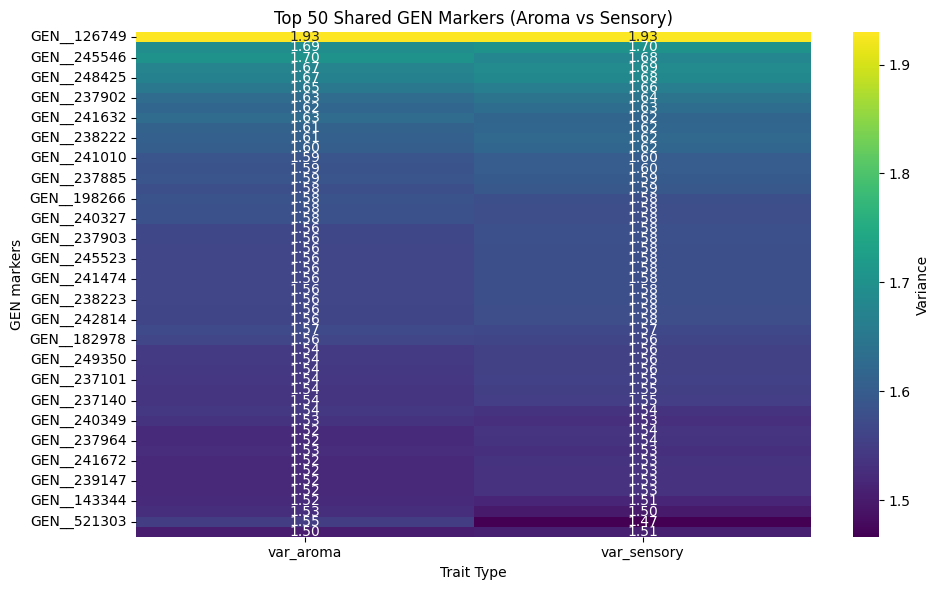

In [ ]:


genes_aroma = [c for c in merged_snp_aroma.columns if c.startswith("GEN__")]
genes_sensory = [c for c in merged_snp_sensory.columns if c.startswith("GEN__")]

shared_genes = list(set(genes_aroma).intersection(set(genes_sensory)))
print("Shared GEN markers:", len(shared_genes))


merged_shared = pd.DataFrame({
    "GEN": shared_genes,
    "var_aroma": [merged_snp_aroma[g].var() for g in shared_genes],
    "var_sensory": [merged_snp_sensory[g].var() for g in shared_genes],
})


merged_shared["combined_score"] = merged_shared["var_aroma"] + merged_shared["var_sensory"]
merged_shared_top50 = merged_shared.sort_values("combined_score", ascending=False).head(50)

print("\nTop 50 shared GEN markers:")
print(merged_shared_top50.head())


# Heatmap

heatmap_data = merged_shared_top50.set_index("GEN")[["var_aroma", "var_sensory"]]

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=True, fmt=".2f",
    cbar_kws={"label": "Variance"}
)
plt.title("Top 50 Shared GEN Markers (Aroma vs Sensory)")
plt.ylabel("GEN markers")
plt.xlabel("Trait Type")
plt.tight_layout()
plt.show()


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_9256\3469706098.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gwas_aroma_top = gwas_aroma.groupby("Trait").apply(
C:\Users\fatemehm\AppData\Local\Temp\ipykernel_9256\3469706098.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gwas_sensory_top = gwas_sensory.groupby("Trait").apply(


Aroma top SNPs: 9000
Sensory top SNPs: 1500
Shared SNPs (Top 500 each): 248


C:\Users\fatemehm\AppData\Local\Temp\ipykernel_9256\3469706098.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: -np.log10(x[["p_fdr_Aroma","p_fdr_Sensory"]].min(axis=1)+1e-10).mean()) \


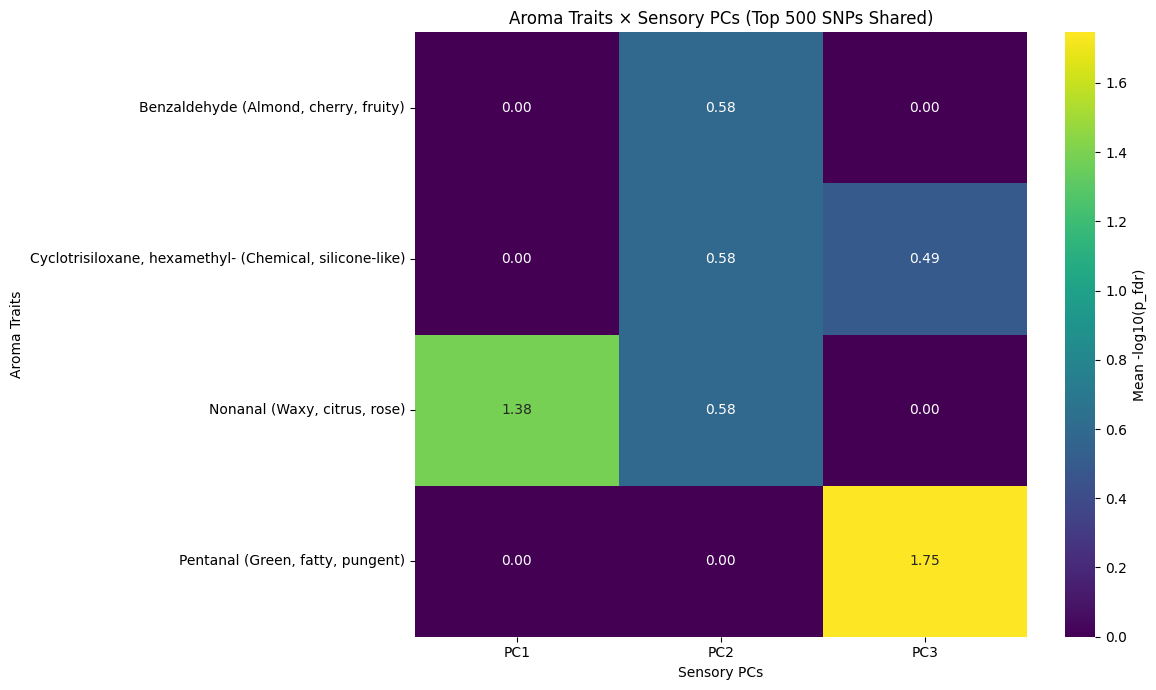

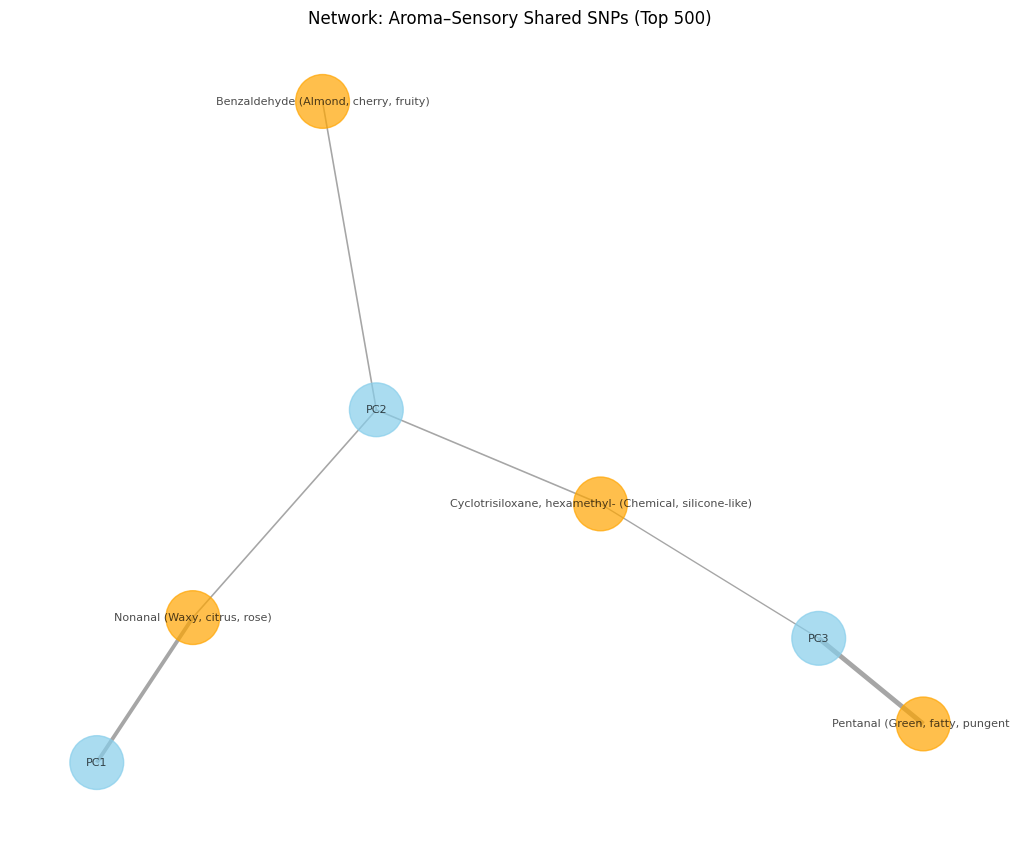

In [ ]:

# 2. Take Top N SNPs per Trait
# ================================
TOPN = 500
gwas_aroma_top = gwas_aroma.groupby("Trait").apply(
    lambda x: x.nsmallest(TOPN, "p_fdr")
).reset_index(drop=True)

gwas_sensory_top = gwas_sensory.groupby("Trait").apply(
    lambda x: x.nsmallest(TOPN, "p_fdr")
).reset_index(drop=True)

print(f"Aroma top SNPs: {len(gwas_aroma_top)}")
print(f"Sensory top SNPs: {len(gwas_sensory_top)}")

# ================================
# 3. Merge to find shared SNPs
# ================================
shared = pd.merge(
    gwas_aroma_top, gwas_sensory_top,
    on="SNP", suffixes=("_Aroma", "_Sensory")
)

print(f"Shared SNPs (Top {TOPN} each): {len(shared)}")

# ================================
# 4. Compute mean -log10(p_fdr)
# ================================
heatmap_data = shared.groupby(["Trait_Aroma", "Trait_Sensory"]) \
    .apply(lambda x: -np.log10(x[["p_fdr_Aroma","p_fdr_Sensory"]].min(axis=1)+1e-10).mean()) \
    .unstack(fill_value=0)

# ================================
# 5. Heatmap
# ================================
plt.figure(figsize=(12,7))
sns.heatmap(
    heatmap_data, cmap="viridis", annot=True, fmt=".2f",
    cbar_kws={"label": "Mean -log10(p_fdr)"}
)
plt.title(f"Aroma Traits × Sensory PCs (Top {TOPN} SNPs Shared)")
plt.ylabel("Aroma Traits")
plt.xlabel("Sensory PCs")
plt.tight_layout()
plt.show()

# ================================
# 6. Network Plot (Triangle)
# ================================
# Build graph
G = nx.Graph()

# Add nodes
for aroma in heatmap_data.index:
    G.add_node(aroma, bipartite="Aroma", color="orange")

for sensory in heatmap_data.columns:
    G.add_node(sensory, bipartite="Sensory", color="skyblue")

# Add edges weighted by mean significance
for aroma in heatmap_data.index:
    for sensory in heatmap_data.columns:
        weight = heatmap_data.loc[aroma, sensory]
        if weight > 0:  # only keep nonzero
            G.add_edge(aroma, sensory, weight=weight)

# Draw network
pos = nx.spring_layout(G, seed=42)
edge_weights = [d["weight"]*2 for _,_,d in G.edges(data=True)]
colors = ["orange" if G.nodes[n]["bipartite"]=="Aroma" else "skyblue" for n in G.nodes()]

plt.figure(figsize=(10,8))
nx.draw(G, pos, with_labels=True, node_color=colors,
        node_size=1500, font_size=8,
        width=edge_weights, edge_color="gray", alpha=0.7)
plt.title(f"Network: Aroma–Sensory Shared SNPs (Top {TOPN})")
plt.show()


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


shared_snps = set(gwas_aroma["SNP"]).intersection(set(gwas_sensory["SNP"]))
aroma_shared = gwas_aroma[gwas_aroma["SNP"].isin(shared_snps)]
sensory_shared = gwas_sensory[gwas_sensory["SNP"].isin(shared_snps)]

merged_shared = pd.merge(
    aroma_shared[["SNP", "Trait", "p_fdr"]],
    sensory_shared[["SNP", "Trait", "p_fdr"]],
    on="SNP",
    suffixes=("_Aroma", "_Sensory")
)


merged_shared["min_p"] = merged_shared[["p_fdr_Aroma", "p_fdr_Sensory"]].min(axis=1)
top_shared = merged_shared.nsmallest(20, "min_p")


G = nx.Graph()

for aroma in top_shared["Trait_Aroma"].unique():
    G.add_node(aroma, type="aroma")
for sensory in top_shared["Trait_Sensory"].unique():
    G.add_node(sensory, type="sensory")
for snp in top_shared["SNP"].unique():
    G.add_node(snp, type="gene")

for _, row in top_shared.iterrows():
    G.add_edge(row["Trait_Aroma"], row["SNP"])
    G.add_edge(row["SNP"], row["Trait_Sensory"])


pos = nx.spring_layout(G, seed=42)

node_colors, node_sizes = [], []
for n in G.nodes(data=True):
    if n[1]['type'] == "aroma":
        node_colors.append("orange")
        node_sizes.append(2000)
    elif n[1]['type'] == "sensory":
        node_colors.append("skyblue")
        node_sizes.append(2000)
    else:  # gene
        node_colors.append("lightgreen")
        node_sizes.append(1000)

plt.figure(figsize=(12, 8))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=node_sizes,
    font_size=9,
    font_weight="bold",
    edge_color="gray"
)

orange_patch = mpatches.Patch(color="orange", label="Aroma Traits")
blue_patch = mpatches.Patch(color="skyblue", label="Sensory Traits")
green_patch = mpatches.Patch(color="lightgreen", label="Genes (SNPs)")
plt.legend(handles=[orange_patch, blue_patch, green_patch], loc="best")

plt.title("Top 5 Shared Genes: Aroma – Gene – Sensory", fontsize=16)
plt.show()


NameError: name 'gwas_aroma' is not defined

In [ ]:

top_aroma_snps = gwas_aroma.sort_values("p_fdr").head(20)["SNP"]
top_sensory_snps = gwas_sensory.sort_values("p_fdr").head(20)["SNP"]

selected_snps = set(top_aroma_snps).union(set(top_sensory_snps)).union(shared_snps)

aroma_df = gwas_aroma[gwas_aroma["SNP"].isin(selected_snps)]
sensory_df = gwas_sensory[gwas_sensory["SNP"].isin(selected_snps)]


G = nx.Graph()
for aroma in aroma_df["Trait"].unique():
    G.add_node(aroma, type="aroma")

for sensory in sensory_df["Trait"].unique():
    G.add_node(sensory, type="sensory")

for _, row in aroma_df.iterrows():
    snp = row["SNP"]
    G.add_node(snp, type="gene")
    G.add_edge(row["Trait"], snp)

for _, row in sensory_df.iterrows():
    snp = row["SNP"]
    G.add_node(snp, type="gene")
    G.add_edge(snp, row["Trait"])

import networkx as nx
import matplotlib.pyplot as plt

# choose layout based on graph size
def choose_layout(G, threshold=200):
    if len(G.nodes) > threshold:
        print(f"Graph has {len(G.nodes)} nodes → using spring_layout")
        return nx.spring_layout(G, k=0.5, iterations=50, seed=42)
    else:
        print(f"Graph has {len(G.nodes)} nodes → using kamada_kawai_layout")
        return nx.kamada_kawai_layout(G)

# build graph (your existing code)
G = nx.Graph()
for aroma in aroma_df["Trait"].unique():
    G.add_node(aroma, type="aroma")

for sensory in sensory_df["Trait"].unique():
    G.add_node(sensory, type="sensory")

for _, row in aroma_df.iterrows():
    snp = row["SNP"]
    G.add_node(snp, type="gene")
    G.add_edge(row["Trait"], snp)

for _, row in sensory_df.iterrows():
    snp = row["SNP"]
    G.add_node(snp, type="gene")
    G.add_edge(snp, row["Trait"])


# colors
node_colors = []
for n, d in G.nodes(data=True):
    if d['type'] == "aroma":
        node_colors.append("orange")
    elif d['type'] == "sensory":
        node_colors.append("skyblue")
    else:
        node_colors.append("lightgreen")

# draw
H = G.subgraph(list(selected_snps)[:100])  # keep 100 SNPs
pos = nx.spring_layout(H, seed=42)
nx.draw(H, pos, node_size=50, font_size=6)
plt.show()

plt.title("Network: Top Aroma + Sensory SNPs (Shared + Unique)", fontsize=16)
plt.show()

